(mmm_funnel_from_yml)=
# Building funnel-aware MMMs from YAML

Standard MMM YAML specs describe a **flat** model: channels go in, adstock and saturation transform them, and the result predicts the target. Funnel-aware MMMs add structure — upper-funnel spend creates lower-funnel demand, which then drives the target. The {ref}`mmm_funnel_mueffect` and {ref}`mmm_funnel_mueffect_advanced` notebooks build that structure in Python; **this notebook shows the same experiments through YAML configuration**.

The key YAML extensions are:

| Key | What it does |
|-----|-------------|
| `model:` | Standard MMM kwargs — channels, adstock, saturation, dims |
| `extra_vars:` | Columns that are *not* channels but must survive DataFrame → Dataset conversion (mediators, controls used inside custom effects) |
| `effects:` | Custom `MuEffect` subclasses that add nodes and likelihoods to the PyMC graph |

For each model below we show a hand-drawn **causal DAG** (what the specification claims about the world), print the YAML spec, and render the **PyMC graph** (what the builder actually wires up).

```{important}
`FunnelEffect` and `GeoFunnelEffect` are defined **in this notebook** (not in the library yet). YAML references them through short names registered on the builder `REGISTRY`.
```

```{note}
**Reading the causal DAGs.** Grey-filled nodes are observed quantities in the dataset. Dashed-outline nodes are latent. Dashed/dotted edges mark measurement or indicator links rather than ordinary causal paths.
```


In [1]:
import warnings
from pathlib import Path

import arviz as az
import graphviz as gr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pymc.dims as pmd
import pytensor.tensor as pt
import xarray as xr
from IPython.display import Markdown, display
from pydantic import InstanceOf
from pymc.model.transform.conditioning import do
from pymc_extras.prior import Prior

from pymc_marketing.mmm import (
    AdstockTransformation,
    SaturationTransformation,
)
from pymc_marketing.mmm.additive_effect import (
    DataVarMuEffect,
    IncrementalitySpec,
)
from pymc_marketing.mmm.builders.factories import REGISTRY
from pymc_marketing.mmm.builders.yaml import build_mmm_from_yaml
from pymc_marketing.mmm.media_transformation import MediaTransformation
from pymc_marketing.paths import data_dir

warnings.filterwarnings("ignore")

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [12, 7]
plt.rcParams["figure.dpi"] = 100

rng = np.random.default_rng(42)
CONFIG_DIR = data_dir / "config_files"
sample_kwargs = dict(chains=2, tune=500, draws=500, target_accept=0.9, random_seed=rng)


def show_yaml(path: Path) -> None:
    """Print a YAML config so readers can follow along in the notebook."""
    text = path.read_text()
    display(Markdown(f"**`{path.name}`**\n\n```yaml\n{text}```"))


def show_graph(mmm, title: str | None = None) -> None:
    """Display the PyMC graph built from a YAML spec."""
    if title:
        display(Markdown(f"**{title}** — PyMC graph"))
    display(mmm.graphviz())


def _node_attrs(kind: str) -> dict:
    if kind == "observed":
        return {"style": "filled", "fillcolor": "lightgray", "shape": "ellipse"}
    if kind == "latent":
        return {"style": "dashed", "shape": "ellipse"}
    raise ValueError(kind)


def draw_causal_dag(
    nodes: list[tuple[str, str, str]],
    edges: list,
    *,
    title: str | None = None,
    rankdir: str = "LR",
) -> gr.Digraph:
    """Hand-drawn causal DAG. kind is 'observed' or 'latent'."""
    g = gr.Digraph()
    g.attr(rankdir=rankdir)
    if title:
        g.attr(label=title, labelloc="t", fontsize="14")
    for node_id, label, kind in nodes:
        g.node(node_id, label, **_node_attrs(kind))
    for edge in edges:
        if len(edge) == 2:
            g.edge(edge[0], edge[1])
        else:
            g.edge(edge[0], edge[1], **edge[2])
    return g


def show_causal_dag(*args, **kwargs) -> None:
    display(draw_causal_dag(*args, **kwargs))

/Users/benjamv/wt/pymc-marketing/funnel-from-yaml/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Custom funnel effects

YAML `effects:` entries reference Python classes. The builder looks up `class: FunnelEffect` in `REGISTRY`. We port the effect logic from the hand-wired notebooks here and register the short names before calling `build_mmm_from_yaml`.

Each effect's `create_effect` method adds the funnel subgraph: a latent demand node, extra likelihoods for observed mediators, and a contribution back to the target equation.


In [2]:
class FunnelEffect(DataVarMuEffect):
    """Intro-topology funnel effect (ported from mmm_funnel_mueffect)."""

    data_vars: list[str] = ["lower_spend", "lower_control"]
    prefix: str = "funnel"
    adstock_uf: InstanceOf[AdstockTransformation]
    saturation_uf: InstanceOf[SaturationTransformation]
    adstock_lf: InstanceOf[AdstockTransformation]
    saturation_lf: InstanceOf[SaturationTransformation]

    def to_dict(self) -> dict:
        """Serialize effect configuration."""
        return {
            "prefix": self.prefix,
            "data_vars": list(self.data_vars),
            "adstock_uf": self.adstock_uf.to_dict(),
            "saturation_uf": self.saturation_uf.to_dict(),
            "adstock_lf": self.adstock_lf.to_dict(),
            "saturation_lf": self.saturation_lf.to_dict(),
        }

    def incrementality_spec(self) -> IncrementalitySpec:
        """Return incrementality settings."""
        return IncrementalitySpec()

    def create_effect(self, mmm):
        """Build the intro funnel subgraph."""
        model = mmm.model
        upper = mmm.channel_data_scaled.isel(channel=0)
        baseline = pmd.HalfNormal(f"{self.prefix}_baseline", sigma=1.0)
        gamma = pmd.HalfNormal(f"{self.prefix}_gamma", sigma=1.0)
        upper_on_lower = self.saturation_uf.apply(
            self.adstock_uf.apply(upper, core_dim="date"), core_dim="date"
        )
        demand = pmd.Deterministic(
            f"{self.prefix}_lower_demand",
            baseline + gamma * model["lower_control"] + upper_on_lower,
        )
        pmd.TruncatedNormal(
            f"{self.prefix}_lower_likelihood",
            mu=demand,
            sigma=pmd.HalfNormal(f"{self.prefix}_sigma", sigma=1.0),
            lower=0.0,
            observed=model["lower_spend"],
        )
        return pmd.Deterministic(
            f"{self.prefix}_effect_contribution",
            self.saturation_lf.apply(
                self.adstock_lf.apply(demand, core_dim="date"), core_dim="date"
            ),
        )


class GeoFunnelEffect(DataVarMuEffect):
    """Advanced geo-panel funnel effect (ported from mmm_funnel_mueffect_advanced)."""

    upper_transform: InstanceOf[MediaTransformation]
    demand_transform: InstanceOf[MediaTransformation]

    model_config = {"arbitrary_types_allowed": True}

    def to_dict(self) -> dict:
        """Serialize effect configuration."""
        return {
            "data_vars": self.data_vars,
            "prefix": self.prefix,
            "upper_transform": self.upper_transform.to_dict(),
            "demand_transform": self.demand_transform.to_dict(),
        }

    def incrementality_spec(self) -> IncrementalitySpec:
        """Return incrementality settings."""
        return IncrementalitySpec(
            additional_carryover_lags=self.demand_transform.adstock.l_max
        )

    def create_effect(self, mmm):
        """Build the geo funnel subgraph."""
        model = mmm.model
        upper_on_demand = self.upper_transform(mmm.channel_data_scaled, dim="date").sum(
            dim="channel"
        )
        baseline = pmd.HalfNormal(f"{self.prefix}_baseline", sigma=1.0, dims=("geo",))
        gamma = pmd.HalfNormal(f"{self.prefix}_gamma", sigma=1.0, dims=("geo",))
        demand = pmd.Deterministic(
            f"{self.prefix}_demand",
            baseline + gamma * model["category_demand"] + upper_on_demand,
        )
        lam_b = pmd.HalfNormal(f"{self.prefix}_lambda", sigma=0.5, dims=("geo",))
        lf_spend = pmd.Deterministic(
            f"{self.prefix}_lf_spend",
            demand + lam_b * model["lf_budget"],
        )
        pmd.TruncatedNormal(
            f"{self.prefix}_lower_spend_likelihood",
            mu=lf_spend,
            sigma=pmd.HalfNormal(f"{self.prefix}_sigma_m", sigma=1.0, dims=("geo",)),
            lower=0.0,
            observed=model["lower_spend"],
        )
        kappa = pmd.HalfNormal(f"{self.prefix}_kappa", sigma=1.0)
        pmd.Normal(
            f"{self.prefix}_search_likelihood",
            mu=kappa * demand,
            sigma=pmd.HalfNormal(f"{self.prefix}_sigma_s", sigma=1.0, dims=("geo",)),
            observed=model["search_volume"],
        )
        return pmd.Deterministic(
            f"{self.prefix}_effect_contribution",
            self.demand_transform(lf_spend, dim="date"),
        )


REGISTRY["FunnelEffect"] = FunnelEffect
REGISTRY["GeoFunnelEffect"] = GeoFunnelEffect

## Part 1 — Intro funnel (national)

We replay the synthetic experiment from {ref}`mmm_funnel_mueffect`: upper-funnel spend (`upper_spend`) drives latent lower-funnel demand, which is observed as noisy `lower_spend` and also feeds the target `y_obs`. An exogenous `lower_control` provides the exclusion restriction.

Three model specs compete:

| Model | YAML idea | Graph shape |
|-------|-----------|-------------|
| **Naive A** | Put `lower_spend` in `channel_columns` | Flat — both channels treated as independent drivers |
| **Naive B** | Only `upper_spend` in channels; ignore lower funnel | Missing the mediator entirely |
| **Funnel** | `effects: [FunnelEffect]` + `extra_vars` | Extra nodes for demand, lower-funnel likelihood, and mediated contribution |


### Step 1 — Generate exogenous covariates

First we draw correlated `upper_spend` and `lower_control` time series. `lower_spend` and `y_obs` are placeholders — we fill them in the next step from the funnel DGP.


In [3]:
n_dates = 130
l_max = 8
date_range = pd.date_range(start="2021-01-04", freq="W-MON", periods=n_dates)

t = np.arange(n_dates) / n_dates
cov_coords = {"date": date_range, "driver": ["upper_spend", "lower_control"]}
with pm.Model(coords=cov_coords) as covariates_model:
    t_data = pm.Data("t", t, dims=("date",))
    L, _, _ = pm.LKJCholeskyCov("L", n=2, eta=100, sd_dist=pm.Exponential.dist(lam=1.0))
    a = pm.Normal("a", mu=0, sigma=1, dims="driver")
    b = pm.Normal("b", mu=0, sigma=1, dims="driver")
    mu_cov = pm.Deterministic(
        "mu_cov", a + b * t_data[..., None], dims=("date", "driver")
    )
    x_raw = pm.MvNormal("x_raw", mu=mu_cov, chol=L, dims=("date", "driver"))
    x = pm.Deterministic("x", pt.softplus(x_raw), dims=("date", "driver"))

x_data = pm.draw(covariates_model.x, draws=1, random_seed=rng)
df_intro = pd.DataFrame(
    {
        "date": date_range,
        "upper_spend": x_data[:, 0],
        "lower_control": x_data[:, 1],
        "lower_spend": np.ones(n_dates),
        "y_dummy": np.ones(n_dates),
    }
)

true_intro = {
    "intercept_contribution": 0.25,
    "adstock_alpha": 0.45,
    "saturation_lam": 4.0,
    "saturation_beta": 0.80,
    "y_sigma": 0.05,
    "funnel_baseline": 0.15,
    "funnel_gamma": 0.25,
    "adstock_uf_alpha": 0.50,
    "sat_uf_lam": 2.5,
    "sat_uf_beta": 1.3,
    "funnel_sigma": 0.04,
    "adstock_lf_alpha": 0.30,
    "sat_lf_lam": 1.2,
    "sat_lf_beta": 1.1,
}
true_intro = {k: np.asarray(v, dtype=float) for k, v in true_intro.items()}
df_intro.head()

,date,upper_spend,lower_control,lower_spend,y_dummy
0,2021-01-04,0.295171,0.162341,1.0,1.0
1,2021-01-11,0.183423,0.068474,1.0,1.0
2,2021-01-18,0.059339,0.329166,1.0,1.0
3,2021-01-25,0.051609,0.341399,1.0,1.0
4,2021-02-01,0.032547,0.278327,1.0,1.0


### Step 2 — Simulate data from the funnel YAML spec

We build the **funnel** model from YAML, fix parameters to known ground truth with `do()`, and draw one prior-predictive sample. That gives us realistic `lower_spend` and `y_obs` tied to the structural DGP. (Covariate draws and the prior-predictive plumbing are in collapsed cells above.)

Notice `extra_vars: [lower_spend, lower_control]` — without this, those columns would be dropped when the builder converts inputs to `xr.Dataset`.


In [4]:
def make_intro_dataset(frame: pd.DataFrame) -> xr.Dataset:
    dates = pd.to_datetime(frame["date"]).to_numpy()
    return xr.Dataset(
        {
            "media": xr.DataArray(
                frame[["upper_spend"]].to_numpy(dtype=float),
                dims=("date", "channel"),
                coords={"date": dates, "channel": ["upper_spend"]},
            ),
            "lower_spend": xr.DataArray(
                frame["lower_spend"].to_numpy(dtype=float),
                dims=("date",),
                coords={"date": dates},
            ),
            "lower_control": xr.DataArray(
                frame["lower_control"].to_numpy(dtype=float),
                dims=("date",),
                coords={"date": dates},
            ),
        }
    )

In [5]:
intro_dgp_path = CONFIG_DIR / "funnel_intro.yml"
show_yaml(intro_dgp_path)

**`funnel_intro.yml`**

```yaml
model:
  class: pymc_marketing.mmm.mmm.MMM
  kwargs:
    date_column: date
    target_column: y_obs
    channel_columns: [upper_spend]
    adstock:
      class: pymc_marketing.mmm.GeometricAdstock
      kwargs: {l_max: 8}
    saturation:
      class: pymc_marketing.mmm.LogisticSaturation
      kwargs: {}
    sampler_config:
      nuts_sampler: nutpie

extra_vars: [lower_spend, lower_control]

effects:
  - class: FunnelEffect
    kwargs:
      adstock_uf:
        class: pymc_marketing.mmm.GeometricAdstock
        kwargs: {l_max: 8, prefix: adstock_uf}
      saturation_uf:
        class: pymc_marketing.mmm.LogisticSaturation
        kwargs: {prefix: sat_uf}
      adstock_lf:
        class: pymc_marketing.mmm.GeometricAdstock
        kwargs: {l_max: 8, prefix: adstock_lf}
      saturation_lf:
        class: pymc_marketing.mmm.LogisticSaturation
        kwargs: {prefix: sat_lf}

original_scale_vars: [channel_contribution, funnel_effect_contribution, y]
```

In [6]:
model_config_gen = {
    "intercept": Prior("Normal", mu=0.3, sigma=0.1),
    "likelihood": Prior("Normal", sigma=Prior("HalfNormal", sigma=0.1)),
}
gen_intro = build_mmm_from_yaml(
    intro_dgp_path,
    X=make_intro_dataset(df_intro),
    y=df_intro["y_dummy"],
    model_kwargs={
        "target_column": "y_dummy",
        "model_config": model_config_gen,
    },
)

**Data-generating funnel model** — PyMC graph

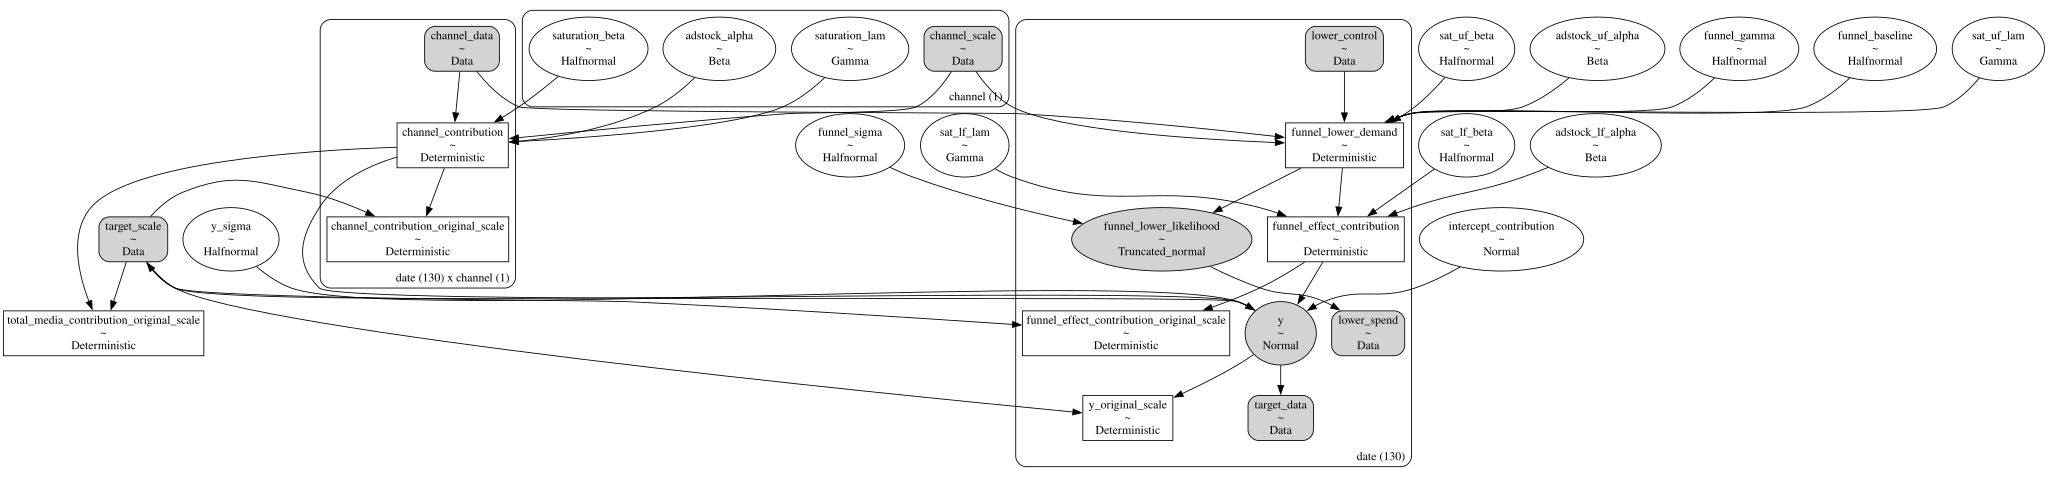

In [7]:
show_graph(gen_intro, "Data-generating funnel model")

In [8]:
channel_dim_vars = {"adstock_alpha", "saturation_lam", "saturation_beta"}
intervention = {
    k: (true_intro[k].reshape(1) if k in channel_dim_vars else true_intro[k])
    for k in true_intro
}
gen_intro.model = do(gen_intro.model, intervention)
with gen_intro.model:
    idata_gen = pm.sample_prior_predictive(
        draws=1,
        var_names=[
            "y_original_scale",
            "channel_contribution_original_scale",
            "funnel_effect_contribution_original_scale",
            "funnel_lower_likelihood",
        ],
        random_seed=rng,
    )
prior = idata_gen["prior"].sel(chain=0, draw=0)
prior_pp = idata_gen["prior_predictive"].sel(chain=0, draw=0)
df_intro["lower_spend"] = prior_pp["funnel_lower_likelihood"].to_numpy().ravel()
df_intro["y_obs"] = prior["y_original_scale"].to_numpy().ravel()
df_intro = df_intro.tail(-l_max).reset_index(drop=True)

X_intro = df_intro[["date", "upper_spend", "lower_spend"]]
X_funnel_intro = make_intro_dataset(df_intro)
y_intro = df_intro["y_obs"]
df_intro[["date", "upper_spend", "lower_spend", "y_obs"]].head()

Sampling: [funnel_lower_likelihood, y]


,date,upper_spend,lower_spend,y_obs
0,2021-03-01,0.762098,0.361573,0.648618
1,2021-03-08,1.635082,0.593898,1.037115
2,2021-03-15,0.133005,0.362800,0.778692
3,2021-03-22,0.277948,0.376564,0.702853
4,2021-03-29,1.976530,0.775497,1.188520


### Causal structure (intro)

The data were simulated from the funnel DGP below. Each competing YAML spec implies a different subgraph.


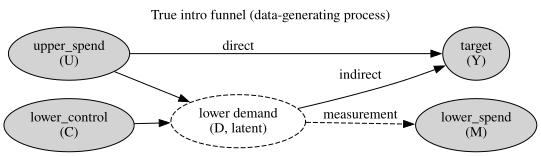

In [9]:
show_causal_dag(
    [
        ("U", "upper_spend\n(U)", "observed"),
        ("C", "lower_control\n(C)", "observed"),
        ("D", "lower demand\n(D, latent)", "latent"),
        ("M", "lower_spend\n(M)", "observed"),
        ("Y", "target\n(Y)", "observed"),
    ],
    [
        ("U", "Y", {"label": "direct"}),
        ("U", "D"),
        ("C", "D"),
        ("D", "M", {"label": "measurement", "style": "dashed"}),
        ("D", "Y", {"label": "indirect"}),
    ],
    title="True intro funnel (data-generating process)",
)

### Step 3 — Fit competing models

For each spec: **causal DAG** (claimed structure) → **YAML** (configuration) → **PyMC graph** (built model). Compare how `channel_columns`, `control_columns`, and `effects:` change the graph shape.


#### Naive A — lower spend as a regular channel

Both `upper_spend` and `lower_spend` sit in `channel_columns`. The graph has two parallel media paths into `y` with no mediation link between them.


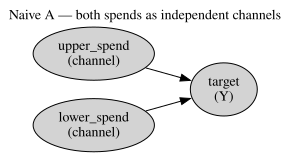

In [10]:
show_causal_dag(
    [
        ("U", "upper_spend\n(channel)", "observed"),
        ("M", "lower_spend\n(channel)", "observed"),
        ("Y", "target\n(Y)", "observed"),
    ],
    [
        ("U", "Y"),
        ("M", "Y"),
    ],
    title="Naive A — both spends as independent channels",
)

In [11]:
naive_a_path = CONFIG_DIR / "funnel_intro_naive_a.yml"
show_yaml(naive_a_path)
m_naive_a = build_mmm_from_yaml(naive_a_path, X=X_intro, y=y_intro)

**`funnel_intro_naive_a.yml`**

```yaml
model:
  class: pymc_marketing.mmm.mmm.MMM
  kwargs:
    date_column: date
    target_column: y_obs
    channel_columns: [upper_spend, lower_spend]
    adstock:
      class: pymc_marketing.mmm.GeometricAdstock
      kwargs: {l_max: 8}
    saturation:
      class: pymc_marketing.mmm.LogisticSaturation
      kwargs: {}
    sampler_config:
      nuts_sampler: nutpie

original_scale_vars: [channel_contribution, y]
```

**Naive A** — PyMC graph

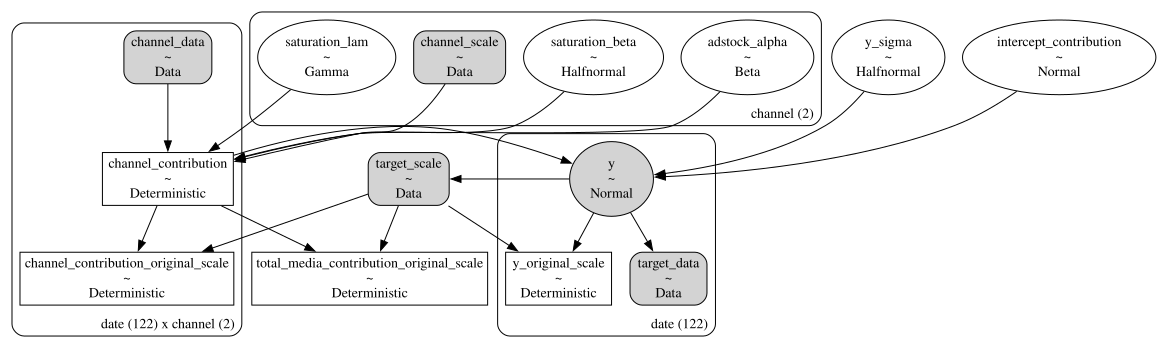

In [12]:
show_graph(m_naive_a, "Naive A")

In [13]:
m_naive_a.fit(X=X_intro, y=y_intro, **sample_kwargs)

NUTS[nutpie]: [y_sigma, adstock_alpha, saturation_lam, saturation_beta, intercept_contribution]


<xarray.DataTree>
Group: /
│   Attributes: (12/24)
│       id:                         eebddbf57febc146
│       model_type:                 MMMM (Multi-Dimensional Marketing Mix Model)
│       version:                    0.0.2
│       sampler_config:             {"nuts_sampler": "nutpie"}
│       model_config:               {"intercept": {"dist": "Normal", "kwargs": {"...
│       __serialization_version__:  1
│       ...                         ...
│       scaling:                    {"__type__": "pymc_marketing.mmm.scaling.Scal...
│       dag:                        null
│       treatment_nodes:            null
│       outcome_node:               null
│       mu_effects:                 []
│       cost_per_unit:              null
├── Group: /posterior
│       Dimensions:                                  (chain: 2, draw: 500, channel: 2,
│                                                     date: 122)
│       Coordinates:
│         * chain                                    (chain) int64 16B 0 1
│         * draw                                     (draw) int64 4kB 0 1 2 ... 498 499
│         * channel                                  (channel) object 16B 'upper_spen...
│         * date                                     (date) datetime64[ns] 976B 2021-...
│       Data variables:
│           intercept_contribution                   (chain, draw) float64 8kB 0.194 ...
│           y_sigma                                  (chain, draw) float64 8kB 0.0269...
│           adstock_alpha                            (chain, draw, channel) float64 16kB ...
│           saturation_lam                           (chain, draw, channel) float64 16kB ...
│           saturation_beta                          (chain, draw, channel) float64 16kB ...
│           y_original_scale                         (chain, draw, date) float64 976kB ...
│           channel_contribution_original_scale      (chain, draw, date, channel) float64 2MB ...
│           total_media_contribution_original_scale  (chain, draw) float64 8kB 82.66 ...
│           channel_contribution                     (chain, draw, date, channel) float64 2MB ...
│       Attributes:
│           created_at:                 2026-08-17T12:48:48.984171+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                ['chain', 'draw']
│           inference_library:          nutpie
│           inference_library_version:  0.16.11
│           sampling_time:              0.9242737293243408
│           tuning_steps:               500
│           pymc_marketing_version:     1.0.0
├── Group: /sample_stats
│       Dimensions:                   (chain: 2, draw: 500)
│       Coordinates:
│         * chain                     (chain) int64 16B 0 1
│         * draw                      (draw) int64 4kB 0 1 2 3 4 ... 495 496 497 498 499
│       Data variables: (12/20)
│           depth                     (chain, draw) uint64 8kB 5 4 5 6 6 7 ... 7 5 4 5 5
│           maxdepth_reached          (chain, draw) bool 1kB False False ... False False
│           step_size                 (chain, draw) float64 8kB 0.1204 0.1255 ... 0.1264
│           transformation_update_id  (chain, draw) int64 8kB 0 0 0 0 0 0 ... 0 0 0 0 0
│           step_size_bar             (chain, draw) float64 8kB 0.1245 0.1245 ... 0.1209
│           mean_tree_accept          (chain, draw) float64 8kB 0.87 0.8713 ... 0.996
│           ...                        ...
│           fisher_distance           (chain, draw) float64 8kB 765.2 693.2 ... 41.94
│           transformation_index      (chain, draw) int64 8kB 423 423 423 ... 423 423
│           diverging                 (chain, draw) bool 1kB False False ... False False
│           divergence_draw           (chain, draw) uint64 8kB 0 0 0 0 0 0 ... 0 0 0 0 0
│           divergence_message        (chain, draw) object 8kB None None ... None None
│           divergence_energy_error

#### Naive B — upper funnel only

Only `upper_spend` is a channel. Lower-funnel spend is ignored entirely — the graph has no nodes for it.


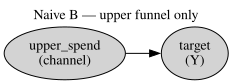

In [14]:
show_causal_dag(
    [
        ("U", "upper_spend\n(channel)", "observed"),
        ("Y", "target\n(Y)", "observed"),
    ],
    [("U", "Y")],
    title="Naive B — upper funnel only",
)

In [15]:
naive_b_path = CONFIG_DIR / "funnel_intro_naive_b.yml"
show_yaml(naive_b_path)
m_naive_b = build_mmm_from_yaml(naive_b_path, X=X_intro, y=y_intro)

**`funnel_intro_naive_b.yml`**

```yaml
model:
  class: pymc_marketing.mmm.mmm.MMM
  kwargs:
    date_column: date
    target_column: y_obs
    channel_columns: [upper_spend]
    adstock:
      class: pymc_marketing.mmm.GeometricAdstock
      kwargs: {l_max: 8}
    saturation:
      class: pymc_marketing.mmm.LogisticSaturation
      kwargs: {}
    sampler_config:
      nuts_sampler: nutpie

original_scale_vars: [channel_contribution, y]
```

**Naive B** — PyMC graph

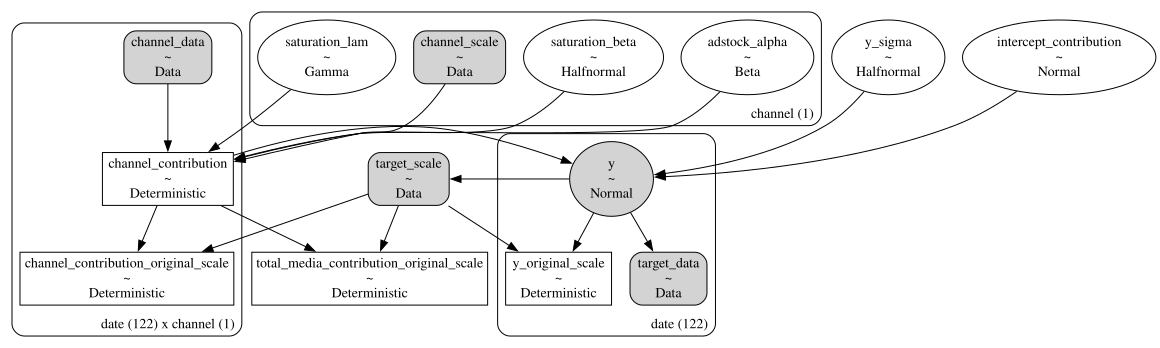

In [16]:
show_graph(m_naive_b, "Naive B")

In [17]:
m_naive_b.fit(X=X_intro, y=y_intro, **sample_kwargs)

NUTS[nutpie]: [y_sigma, adstock_alpha, saturation_lam, saturation_beta, intercept_contribution]


<xarray.DataTree>
Group: /
│   Attributes: (12/24)
│       id:                         eebddbf57febc146
│       model_type:                 MMMM (Multi-Dimensional Marketing Mix Model)
│       version:                    0.0.2
│       sampler_config:             {"nuts_sampler": "nutpie"}
│       model_config:               {"intercept": {"dist": "Normal", "kwargs": {"...
│       __serialization_version__:  1
│       ...                         ...
│       scaling:                    {"__type__": "pymc_marketing.mmm.scaling.Scal...
│       dag:                        null
│       treatment_nodes:            null
│       outcome_node:               null
│       mu_effects:                 []
│       cost_per_unit:              null
├── Group: /posterior
│       Dimensions:                                  (chain: 2, draw: 500, channel: 1,
│                                                     date: 122)
│       Coordinates:
│         * chain                                    (chain) int64 16B 0 1
│         * draw                                     (draw) int64 4kB 0 1 2 ... 498 499
│         * channel                                  (channel) object 8B 'upper_spend'
│         * date                                     (date) datetime64[ns] 976B 2021-...
│       Data variables:
│           intercept_contribution                   (chain, draw) float64 8kB 0.2238...
│           y_sigma                                  (chain, draw) float64 8kB 0.0325...
│           adstock_alpha                            (chain, draw, channel) float64 8kB ...
│           saturation_lam                           (chain, draw, channel) float64 8kB ...
│           saturation_beta                          (chain, draw, channel) float64 8kB ...
│           y_original_scale                         (chain, draw, date) float64 976kB ...
│           channel_contribution_original_scale      (chain, draw, date, channel) float64 976kB ...
│           total_media_contribution_original_scale  (chain, draw) float64 8kB 77.2 ....
│           channel_contribution                     (chain, draw, date, channel) float64 976kB ...
│       Attributes:
│           created_at:                 2026-08-17T12:48:55.338670+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                ['chain', 'draw']
│           inference_library:          nutpie
│           inference_library_version:  0.16.11
│           sampling_time:              0.15735602378845215
│           tuning_steps:               500
│           pymc_marketing_version:     1.0.0
├── Group: /sample_stats
│       Dimensions:                   (chain: 2, draw: 500)
│       Coordinates:
│         * chain                     (chain) int64 16B 0 1
│         * draw                      (draw) int64 4kB 0 1 2 3 4 ... 495 496 497 498 499
│       Data variables: (12/20)
│           depth                     (chain, draw) uint64 8kB 4 4 2 4 4 4 ... 2 4 3 4 3
│           maxdepth_reached          (chain, draw) bool 1kB False False ... False False
│           step_size                 (chain, draw) float64 8kB 0.2604 0.3103 ... 0.3029
│           transformation_update_id  (chain, draw) int64 8kB 0 0 0 0 0 0 ... 0 0 0 0 0
│           step_size_bar             (chain, draw) float64 8kB 0.2849 0.2849 ... 0.2929
│           mean_tree_accept          (chain, draw) float64 8kB 0.9995 0.9297 ... 0.9994
│           ...                        ...
│           fisher_distance           (chain, draw) float64 8kB 52.31 15.73 ... 88.35
│           transformation_index      (chain, draw) int64 8kB 422 422 422 ... 423 423
│           diverging                 (chain, draw) bool 1kB False False ... False False
│           divergence_draw           (chain, draw) uint64 8kB 0 0 0 0 0 0 ... 0 0 0 0 0
│           divergence_message        (chain, draw) object 8kB None None ... None None
│           divergence_energy_er

#### Funnel — structural mediation via `FunnelEffect`

`effects:` wires in `FunnelEffect`, which adds `funnel_lower_demand`, a second likelihood on `lower_spend`, and `funnel_effect_contribution` back to the target. `extra_vars` keeps `lower_control` available inside the effect.


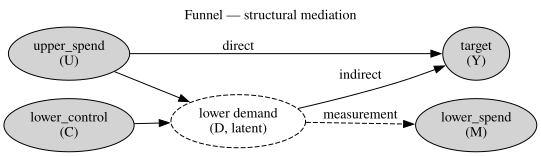

In [18]:
show_causal_dag(
    [
        ("U", "upper_spend\n(U)", "observed"),
        ("C", "lower_control\n(C)", "observed"),
        ("D", "lower demand\n(D, latent)", "latent"),
        ("M", "lower_spend\n(M)", "observed"),
        ("Y", "target\n(Y)", "observed"),
    ],
    [
        ("U", "Y", {"label": "direct"}),
        ("U", "D"),
        ("C", "D"),
        ("D", "M", {"label": "measurement", "style": "dashed"}),
        ("D", "Y", {"label": "indirect"}),
    ],
    title="Funnel — structural mediation",
)

In [19]:
funnel_path = CONFIG_DIR / "funnel_intro.yml"
show_yaml(funnel_path)
m_funnel = build_mmm_from_yaml(funnel_path, X=X_funnel_intro, y=y_intro)

**`funnel_intro.yml`**

```yaml
model:
  class: pymc_marketing.mmm.mmm.MMM
  kwargs:
    date_column: date
    target_column: y_obs
    channel_columns: [upper_spend]
    adstock:
      class: pymc_marketing.mmm.GeometricAdstock
      kwargs: {l_max: 8}
    saturation:
      class: pymc_marketing.mmm.LogisticSaturation
      kwargs: {}
    sampler_config:
      nuts_sampler: nutpie

extra_vars: [lower_spend, lower_control]

effects:
  - class: FunnelEffect
    kwargs:
      adstock_uf:
        class: pymc_marketing.mmm.GeometricAdstock
        kwargs: {l_max: 8, prefix: adstock_uf}
      saturation_uf:
        class: pymc_marketing.mmm.LogisticSaturation
        kwargs: {prefix: sat_uf}
      adstock_lf:
        class: pymc_marketing.mmm.GeometricAdstock
        kwargs: {l_max: 8, prefix: adstock_lf}
      saturation_lf:
        class: pymc_marketing.mmm.LogisticSaturation
        kwargs: {prefix: sat_lf}

original_scale_vars: [channel_contribution, funnel_effect_contribution, y]
```

**Funnel** — PyMC graph

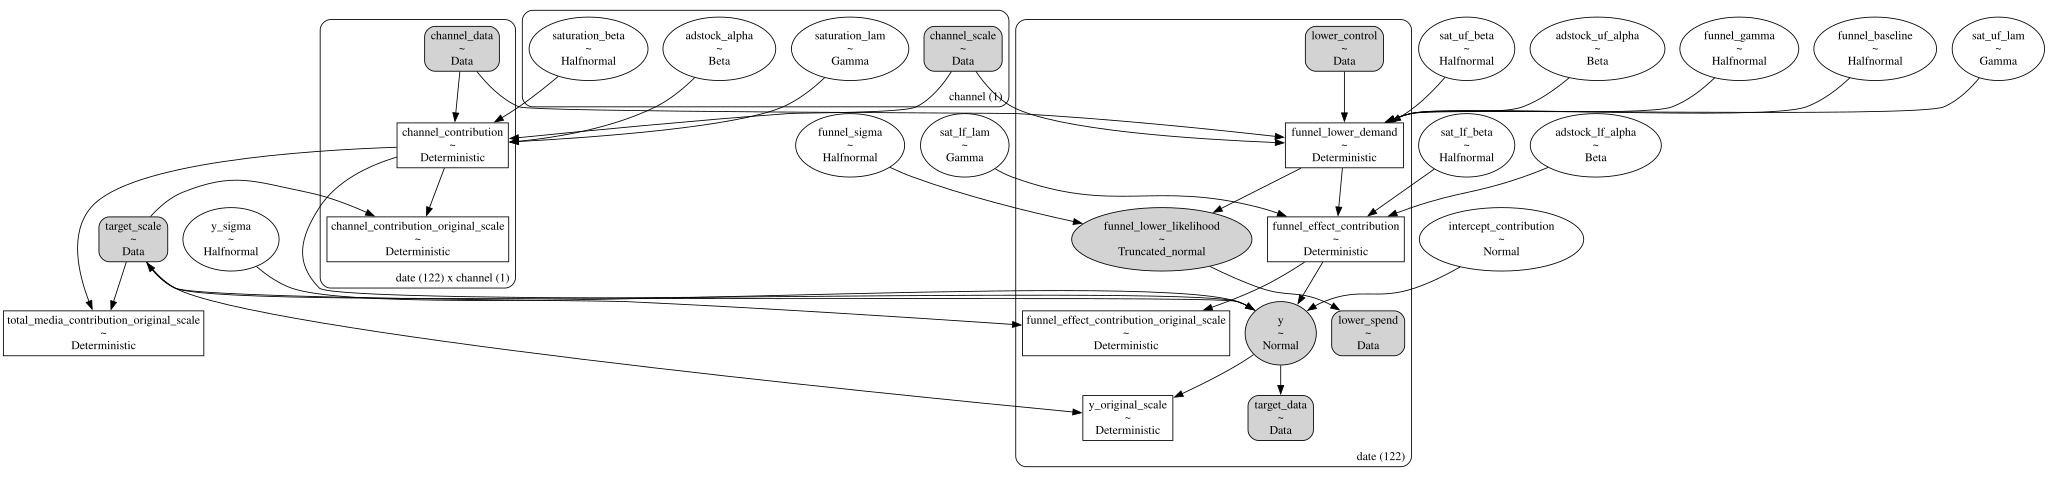

In [20]:
show_graph(m_funnel, "Funnel")

In [21]:
m_funnel.fit(X=X_intro, y=y_intro, **sample_kwargs)
intro_models = {"Naive A": m_naive_a, "Naive B": m_naive_b, "Funnel": m_funnel}

NUTS[nutpie]: [y_sigma, adstock_lf_alpha, adstock_uf_alpha, sat_uf_lam, sat_uf_beta, funnel_gamma, funnel_baseline, sat_lf_lam, sat_lf_beta, adstock_alpha, saturation_lam, saturation_beta, intercept_contribution, funnel_sigma]


### Step 4 — Compare upper-funnel ROAS

With known ground truth, the funnel model should recover upper-funnel credit more faithfully. Naive specs mis-attribute the mediated path.


In [22]:
def upper_roas(model):
    roas = model.incrementality.contribution_over_spend(frequency="all_time")
    return roas.sel(channel="upper_spend")


intro_roas = {label: float(upper_roas(m).mean()) for label, m in intro_models.items()}
pd.Series(intro_roas, name="upper-funnel ROAS").to_frame().T

,Naive A,Naive B,Funnel
upper-funnel ROAS,0.429238,0.633415,0.599742


## Part 2 — Advanced funnel (geo panel)

The geo-panel experiment from {ref}`mmm_funnel_mueffect_advanced` adds:

- a `geo` dimension across three markets,
- two upper-funnel channels (`tv_spend`, `social_spend`),
- two lower-funnel observables (`lower_spend`, `search_volume`) tied to latent demand,
- and a budget shifter (`lf_budget`) on observed lower-funnel spend.

We compare six specs — five naive baselines plus the full `GeoFunnelEffect` model.


### Step 1 — Generate geo-panel covariates


In [23]:
geos = ["north", "south", "west"]
channels = ["tv_spend", "social_spend"]
n_dates_adv = 130
date_range_adv = pd.date_range(start="2021-01-04", freq="W-MON", periods=n_dates_adv)
coords_adv = {"date": date_range_adv, "geo": geos}

t_adv = np.arange(n_dates_adv) / n_dates_adv
week_of_year = date_range_adv.isocalendar().week.to_numpy() / 52.0
season = np.sin(2 * np.pi * week_of_year)
drivers = ["tv_spend", "social_spend", "category_demand"]
geo_size = np.array([1.0, 0.7, 0.45])
level = np.array([0.10, 0.05, 0.30])
trend = np.array([1.20, 0.15, 1.00])
seasonal_amplitude = np.array([0.80, 0.40, 0.70])
cov_coords_adv = {"date": date_range_adv, "geo": geos, "driver": drivers}
with pm.Model(coords=cov_coords_adv) as covariates_model_adv:
    L, _, _ = pm.LKJCholeskyCov(
        "L", n=3, eta=50, sd_dist=pm.Gamma.dist(mu=0.30, sigma=0.05)
    )
    mu_cov = (
        level
        + trend * t_adv[:, None, None]
        + seasonal_amplitude * season[:, None, None]
    )
    x_raw = pm.MvNormal("x_raw", mu=mu_cov, chol=L, dims=("date", "geo", "driver"))
    x = pm.Deterministic("x", pt.softplus(x_raw), dims=("date", "geo", "driver"))

x_adv = (
    pm.draw(covariates_model_adv.x, draws=1, random_seed=rng) * geo_size[None, :, None]
)
media_raw = x_adv[..., :2]
category_demand = x_adv[..., 2] / x_adv[..., 2].max()
lf_budget = 0.15 * category_demand

### Causal structure (geo panel)

The geo experiment has more nodes and two lower-funnel observables. The table in {ref}`mmm_funnel_mueffect_advanced` defines each naive spec; the causal DAGs below show what each YAML version actually conditions on.


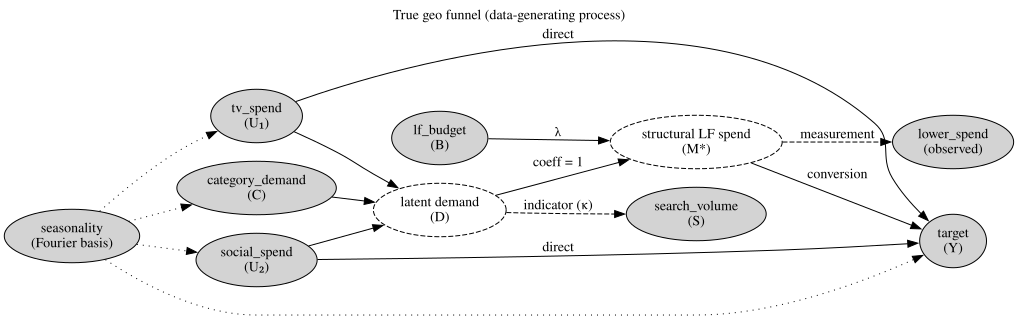

In [24]:
show_causal_dag(
    [
        ("season", "seasonality\n(Fourier basis)", "observed"),
        ("U1", "tv_spend\n(U₁)", "observed"),
        ("U2", "social_spend\n(U₂)", "observed"),
        ("C", "category_demand\n(C)", "observed"),
        ("B", "lf_budget\n(B)", "observed"),
        ("D", "latent demand\n(D)", "latent"),
        ("MS", "structural LF spend\n(M*)", "latent"),
        ("M", "lower_spend\n(observed)", "observed"),
        ("S", "search_volume\n(S)", "observed"),
        ("Y", "target\n(Y)", "observed"),
    ],
    [
        ("season", "U1", {"style": "dotted"}),
        ("season", "U2", {"style": "dotted"}),
        ("season", "C", {"style": "dotted"}),
        ("season", "Y", {"style": "dotted"}),
        ("U1", "Y", {"label": "direct"}),
        ("U2", "Y", {"label": "direct"}),
        ("U1", "D"),
        ("U2", "D"),
        ("C", "D"),
        ("D", "MS", {"label": "coeff = 1"}),
        ("B", "MS", {"label": "λ"}),
        ("MS", "M", {"label": "measurement", "style": "dashed"}),
        ("D", "S", {"label": "indicator (κ)", "style": "dashed"}),
        ("MS", "Y", {"label": "conversion"}),
    ],
    title="True geo funnel (data-generating process)",
)

### Step 2 — Simulate data from the geo funnel YAML spec

Same pattern as Part 1: build from `funnel_advanced.yml`, intervene with known parameters, draw one prior-predictive sample for `y`, `lower_spend`, and `search_volume`. (Geo covariate draws and the prior-predictive plumbing are in collapsed cells above.)


In [25]:
def make_advanced_dataset(
    media, lower_spend, search_volume, cat_demand, budget
) -> xr.Dataset:
    return xr.Dataset(
        {
            "media": xr.DataArray(media, dims=("date", "geo", "channel")),
            "lower_spend": xr.DataArray(lower_spend, dims=("date", "geo")),
            "search_volume": xr.DataArray(search_volume, dims=("date", "geo")),
            "category_demand": xr.DataArray(cat_demand, dims=("date", "geo")),
            "lf_budget": xr.DataArray(budget, dims=("date", "geo")),
        },
        coords={**coords_adv, "channel": channels},
    )


true_adv = {
    "intercept_contribution": np.array([0.35, 0.28, 0.22]),
    "adstock_alpha": np.array([0.55, 0.30]),
    "saturation_lam": np.array([3.0, 4.0]),
    "saturation_beta": np.array([[0.55, 0.35], [0.45, 0.30], [0.35, 0.25]]),
    "gamma_fourier": np.array(
        [
            [0.05, 0.03, 0.02, -0.02],
            [0.04, 0.02, 0.02, -0.01],
            [0.03, 0.02, 0.01, -0.01],
        ]
    ),
    "y_sigma": np.array([0.04, 0.04, 0.04]),
    "funnel_baseline": np.array([0.20, 0.16, 0.12]),
    "funnel_gamma": np.array([0.35, 0.30, 0.25]),
    "adstock_uf_alpha": np.array([0.60, 0.35]),
    "sat_uf_lam": np.array([2.5, 3.0]),
    "sat_uf_beta": np.array([[0.85, 0.55], [0.70, 0.45], [0.55, 0.35]]),
    "funnel_lambda": np.array([0.50, 0.45, 0.40]),
    "funnel_sigma_m": np.array([0.05, 0.05, 0.05]),
    "funnel_kappa": np.array(0.8),
    "funnel_sigma_s": np.array([0.05, 0.05, 0.05]),
    "adstock_lf_alpha": np.array([0.35, 0.30, 0.25]),
    "sat_lf_lam": np.array(1.5),
    "sat_lf_beta": np.array([1.05, 0.90, 0.72]),
}

In [26]:
advanced_dgp_path = CONFIG_DIR / "funnel_advanced.yml"
show_yaml(advanced_dgp_path)

**`funnel_advanced.yml`**

```yaml
model:
  class: pymc_marketing.mmm.mmm.MMM
  kwargs:
    date_column: date
    target_column: y
    channel_columns: [tv_spend, social_spend]
    dims: [geo]
    scaling:
      channel: {method: max, dims: []}
      target: {method: max, dims: []}
    adstock:
      class: pymc_marketing.mmm.GeometricAdstock
      kwargs:
        l_max: 8
        priors:
          alpha:
            distribution: Beta
            alpha: 2
            beta: 3
            dims: channel
    saturation:
      class: pymc_marketing.mmm.LogisticSaturation
      kwargs:
        priors:
          lam:
            distribution: Gamma
            mu: 3.0
            sigma: 1.0
            dims: channel
          beta:
            distribution: HalfNormal
            sigma: 1.0
            dims: [geo, channel]
    yearly_seasonality: 2
    model_config:
      intercept:
        distribution: Normal
        mu: 0.2
        sigma: 0.2
        dims: geo
      gamma_fourier:
        distribution: Normal
        mu: 0
        sigma: 0.1
        dims: [geo, fourier_mode]
      likelihood:
        distribution: Normal
        sigma:
          distribution: HalfNormal
          sigma: 0.5
          dims: geo
        dims: [date, geo]
    sampler_config:
      nuts_sampler: nutpie

extra_vars: [lower_spend, search_volume, category_demand, lf_budget]

effects:
  - class: GeoFunnelEffect
    kwargs:
      data_vars: [lower_spend, search_volume, category_demand, lf_budget]
      prefix: funnel
      upper_transform:
        class: pymc_marketing.mmm.media_transformation.MediaTransformation
        kwargs:
          adstock_first: true
          dims: [geo, channel]
          adstock:
            class: pymc_marketing.mmm.GeometricAdstock
            kwargs:
              l_max: 8
              prefix: adstock_uf
              priors:
                alpha:
                  distribution: Beta
                  alpha: 2
                  beta: 3
                  dims: channel
          saturation:
            class: pymc_marketing.mmm.LogisticSaturation
            kwargs:
              prefix: sat_uf
              priors:
                lam:
                  distribution: Gamma
                  mu: 2.0
                  sigma: 1.0
                  dims: channel
                beta:
                  distribution: HalfNormal
                  sigma: 1.0
                  dims: [geo, channel]
      demand_transform:
        class: pymc_marketing.mmm.media_transformation.MediaTransformation
        kwargs:
          adstock_first: true
          dims: [geo]
          adstock:
            class: pymc_marketing.mmm.GeometricAdstock
            kwargs:
              l_max: 8
              prefix: adstock_lf
              priors:
                alpha:
                  distribution: Beta
                  alpha: 2
                  beta: 3
                  dims: geo
          saturation:
            class: pymc_marketing.mmm.LogisticSaturation
            kwargs:
              prefix: sat_lf
              priors:
                lam:
                  distribution: Gamma
                  mu: 1.5
                  sigma: 0.5
                beta:
                  distribution: HalfNormal
                  sigma: 1.0
                  dims: geo

original_scale_vars: [channel_contribution, funnel_effect_contribution, y]
```

In [27]:
ones = np.ones((n_dates_adv, len(geos)))
ds_gen = make_advanced_dataset(media_raw, ones, ones, category_demand, lf_budget)
y_gen = xr.DataArray(ones, dims=("date", "geo"), coords=coords_adv)

gen_adv = build_mmm_from_yaml(advanced_dgp_path, X=ds_gen, y=y_gen)

**Data-generating geo funnel model** — PyMC graph

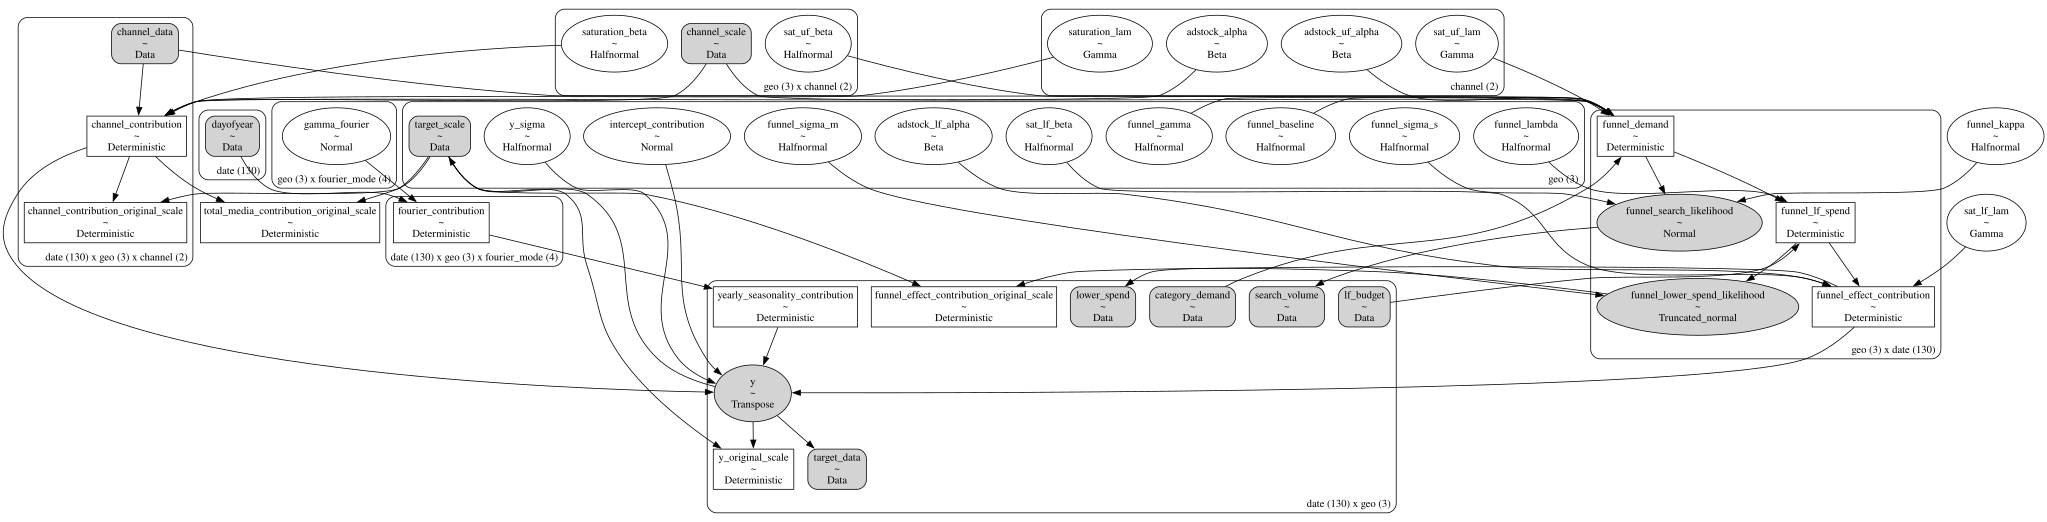

In [28]:
show_graph(gen_adv, "Data-generating geo funnel model")

In [29]:
gen_adv.model = do(gen_adv.model, true_adv)
pp_names = ["funnel_lower_spend_likelihood", "funnel_search_likelihood"]
var_names = [
    "y_original_scale",
    "channel_contribution_original_scale",
    "funnel_effect_contribution_original_scale",
    "funnel_demand",
    "funnel_lf_spend",
]
with gen_adv.model:
    idata_gen_adv = pm.sample_prior_predictive(
        draws=1, var_names=var_names + pp_names, random_seed=rng
    )
prior_adv = idata_gen_adv["prior"].sel(chain=0, draw=0)
prior_pp_adv = idata_gen_adv["prior_predictive"].sel(chain=0, draw=0)

y_obs = prior_adv["y_original_scale"].transpose("date", "geo").to_numpy()
lower_spend_obs = (
    prior_pp_adv["funnel_lower_spend_likelihood"].transpose("date", "geo").to_numpy()
)
search_obs = (
    prior_pp_adv["funnel_search_likelihood"].transpose("date", "geo").to_numpy()
)
y_build = xr.DataArray(y_obs, dims=("date", "geo"), coords=coords_adv)
ds_fit = make_advanced_dataset(
    media_raw, lower_spend_obs, search_obs, category_demand, lf_budget
)

rows = []
for i, date in enumerate(date_range_adv):
    for j, geo in enumerate(geos):
        rows.append(
            {
                "date": date,
                "geo": geo,
                "tv_spend": media_raw[i, j, 0],
                "social_spend": media_raw[i, j, 1],
                "category_demand": category_demand[i, j],
                "t": t_adv[i],
                "y": y_obs[i, j],
            }
        )
df_adv = pd.DataFrame(rows)
y_fit = df_adv["y"]
df_adv.head()

Sampling: [funnel_lower_spend_likelihood, funnel_search_likelihood, y]


,date,geo,tv_spend,social_spend,category_demand,t,y
0,2021-01-04,north,0.817925,0.744014,0.506793,0.000000,1.046623
1,2021-01-04,south,0.491278,0.631490,0.287563,0.000000,0.843103
2,2021-01-04,west,0.388974,0.322429,0.249407,0.000000,0.593673
3,2021-01-11,north,0.719218,0.981642,0.335531,0.007692,1.391984
4,2021-01-11,south,0.386040,0.593155,0.281127,0.007692,1.029424


### Step 3 — Fit competing geo models

Same three-step comparison as Part 1: causal DAG → YAML → PyMC graph. Each naive spec tweaks `channel_columns` or `control_columns`; only the full spec adds `GeoFunnelEffect` with extra likelihoods.


In [30]:
df_naive_a = df_adv.copy()
df_naive_a["lower_spend"] = lower_spend_obs.reshape(-1)
df_naive_c = df_adv.copy()
df_naive_c["search_volume"] = search_obs.reshape(-1)

#### Naive A

Adds `lower_spend` as a third channel — treats it like any other media input.


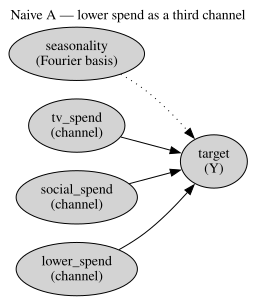

In [31]:
show_causal_dag(
    [
        ("season", "seasonality\n(Fourier basis)", "observed"),
        ("U1", "tv_spend\n(channel)", "observed"),
        ("U2", "social_spend\n(channel)", "observed"),
        ("M", "lower_spend\n(channel)", "observed"),
        ("Y", "target\n(Y)", "observed"),
    ],
    [
        ("season", "Y", {"style": "dotted"}),
        ("U1", "Y"),
        ("U2", "Y"),
        ("M", "Y"),
    ],
    title="Naive A — lower spend as a third channel",
)

In [32]:
path = CONFIG_DIR / "funnel_advanced_naive_a.yml"
show_yaml(path)
X_frame = df_naive_a.drop(columns=["y"])
X_build = X_frame
m_naive_a = build_mmm_from_yaml(path, X=X_build, y=y_build)

**`funnel_advanced_naive_a.yml`**

```yaml
model:
  class: pymc_marketing.mmm.mmm.MMM
  kwargs:
    date_column: date
    target_column: y
    channel_columns: [tv_spend, social_spend, lower_spend]
    dims: [geo]
    scaling:
      channel: {method: max, dims: []}
      target: {method: max, dims: []}
    adstock:
      class: pymc_marketing.mmm.GeometricAdstock
      kwargs:
        l_max: 8
        priors:
          alpha:
            distribution: Beta
            alpha: 2
            beta: 3
            dims: channel
    saturation:
      class: pymc_marketing.mmm.LogisticSaturation
      kwargs:
        priors:
          lam:
            distribution: Gamma
            mu: 3.0
            sigma: 1.0
            dims: channel
          beta:
            distribution: HalfNormal
            sigma: 1.0
            dims: [geo, channel]
    yearly_seasonality: 2
    model_config:
      intercept:
        distribution: Normal
        mu: 0.2
        sigma: 0.2
        dims: geo
      gamma_fourier:
        distribution: Normal
        mu: 0
        sigma: 0.1
        dims: [geo, fourier_mode]
      likelihood:
        distribution: Normal
        sigma:
          distribution: HalfNormal
          sigma: 0.5
          dims: geo
        dims: [date, geo]
    sampler_config:
      nuts_sampler: nutpie

original_scale_vars: [channel_contribution, y]
```

**Naive A** — PyMC graph

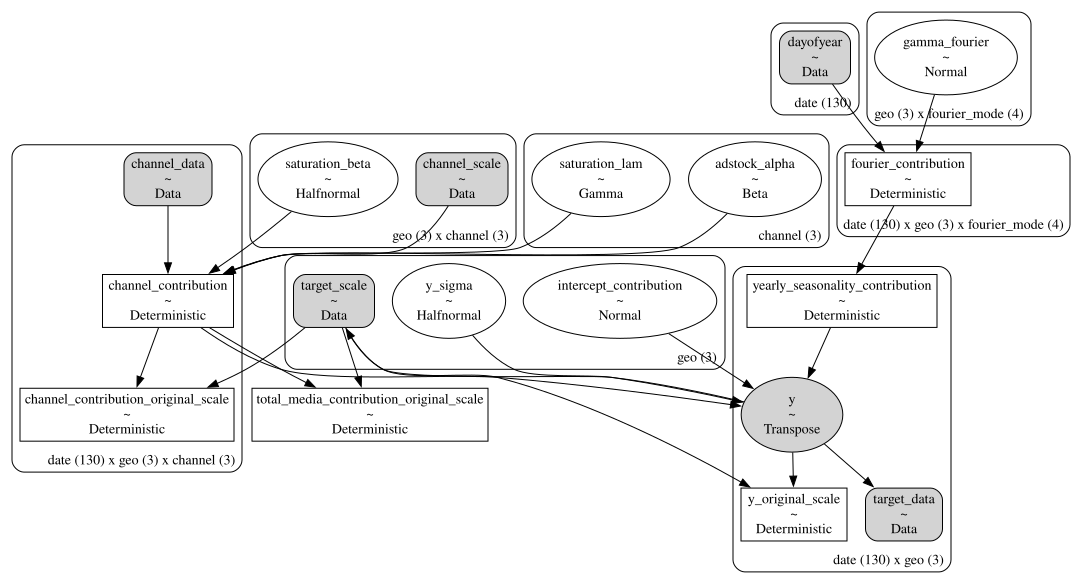

In [33]:
show_graph(m_naive_a, "Naive A")

In [34]:
m_naive_a.fit(X=X_frame, y=y_fit, **sample_kwargs)

NUTS[nutpie]: [y_sigma, gamma_fourier, adstock_alpha, saturation_lam, saturation_beta, intercept_contribution]


<xarray.DataTree>
Group: /
│   Attributes: (12/24)
│       id:                         c2648fd5b170263b
│       model_type:                 MMMM (Multi-Dimensional Marketing Mix Model)
│       version:                    0.0.2
│       sampler_config:             {"nuts_sampler": "nutpie"}
│       model_config:               {"intercept": {"dist": "Normal", "kwargs": {"...
│       __serialization_version__:  1
│       ...                         ...
│       scaling:                    {"__type__": "pymc_marketing.mmm.scaling.Scal...
│       dag:                        null
│       treatment_nodes:            null
│       outcome_node:               null
│       mu_effects:                 []
│       cost_per_unit:              null
├── Group: /posterior
│       Dimensions:                                  (chain: 2, draw: 500, geo: 3,
│                                                     fourier_mode: 4, channel: 3,
│                                                     date: 130)
│       Coordinates:
│         * chain                                    (chain) int64 16B 0 1
│         * draw                                     (draw) int64 4kB 0 1 2 ... 498 499
│         * geo                                      (geo) object 24B 'north' ... 'west'
│         * fourier_mode                             (fourier_mode) object 32B 'sin_1...
│         * channel                                  (channel) object 24B 'tv_spend' ...
│         * date                                     (date) datetime64[ns] 1kB 2021-0...
│       Data variables:
│           gamma_fourier                            (chain, draw, geo, fourier_mode) float64 96kB ...
│           intercept_contribution                   (chain, draw, geo) float64 24kB ...
│           y_sigma                                  (chain, draw, geo) float64 24kB ...
│           adstock_alpha                            (chain, draw, channel) float64 24kB ...
│           saturation_lam                           (chain, draw, channel) float64 24kB ...
│           saturation_beta                          (chain, draw, geo, channel) float64 72kB ...
│           y_original_scale                         (chain, draw, date, geo) float64 3MB ...
│           channel_contribution_original_scale      (chain, draw, date, geo, channel) float64 9MB ...
│           total_media_contribution_original_scale  (chain, draw) float64 8kB 465.1 ...
│           yearly_seasonality_contribution          (chain, draw, date, geo) float64 3MB ...
│           fourier_contribution                     (chain, draw, date, geo, fourier_mode) float64 12MB ...
│           channel_contribution                     (chain, draw, date, geo, channel) float64 9MB ...
│       Attributes:
│           created_at:                 2026-08-17T12:49:53.454219+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                ['chain', 'draw']
│           inference_library:          nutpie
│           inference_library_version:  0.16.11
│           sampling_time:              13.170156955718994
│           tuning_steps:               500
│           pymc_marketing_version:     1.0.0
├── Group: /sample_stats
│       Dimensions:                   (chain: 2, draw: 500)
│       Coordinates:
│         * chain                     (chain) int64 16B 0 1
│         * draw                      (draw) int64 4kB 0 1 2 3 4 ... 495 496 497 498 499
│       Data variables: (12/20)
│           depth                     (chain, draw) uint64 8kB 8 8 8 8 7 6 ... 6 7 8 8 8
│           maxdepth_reached          (chain, draw) bool 1kB False False ... False False
│           step_size                 (chain, draw) float64 8kB 0.06947 ... 0.06649
│           transformation_update_id  (chain, draw) int64 8kB 0 0 0 0 0 0 ... 0 0 0 0 0
│           step_size_bar             (chain, draw) float64 8kB 0.07353 ... 0.06527
│           mean_tree_accept  

#### Naive B

Upper channels only — no lower-funnel variables at all.


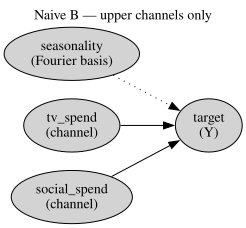

In [35]:
show_causal_dag(
    [
        ("season", "seasonality\n(Fourier basis)", "observed"),
        ("U1", "tv_spend\n(channel)", "observed"),
        ("U2", "social_spend\n(channel)", "observed"),
        ("Y", "target\n(Y)", "observed"),
    ],
    [
        ("season", "Y", {"style": "dotted"}),
        ("U1", "Y"),
        ("U2", "Y"),
    ],
    title="Naive B — upper channels only",
)

In [36]:
path = CONFIG_DIR / "funnel_advanced_naive_b.yml"
show_yaml(path)
X_frame = df_adv.drop(columns=["y"])
X_build = X_frame
m_naive_b = build_mmm_from_yaml(path, X=X_build, y=y_build)

**`funnel_advanced_naive_b.yml`**

```yaml
model:
  class: pymc_marketing.mmm.mmm.MMM
  kwargs:
    date_column: date
    target_column: y
    channel_columns: [tv_spend, social_spend]
    dims: [geo]
    scaling:
      channel: {method: max, dims: []}
      target: {method: max, dims: []}
    adstock:
      class: pymc_marketing.mmm.GeometricAdstock
      kwargs:
        l_max: 8
        priors:
          alpha:
            distribution: Beta
            alpha: 2
            beta: 3
            dims: channel
    saturation:
      class: pymc_marketing.mmm.LogisticSaturation
      kwargs:
        priors:
          lam:
            distribution: Gamma
            mu: 3.0
            sigma: 1.0
            dims: channel
          beta:
            distribution: HalfNormal
            sigma: 1.0
            dims: [geo, channel]
    yearly_seasonality: 2
    model_config:
      intercept:
        distribution: Normal
        mu: 0.2
        sigma: 0.2
        dims: geo
      gamma_fourier:
        distribution: Normal
        mu: 0
        sigma: 0.1
        dims: [geo, fourier_mode]
      likelihood:
        distribution: Normal
        sigma:
          distribution: HalfNormal
          sigma: 0.5
          dims: geo
        dims: [date, geo]
    sampler_config:
      nuts_sampler: nutpie

original_scale_vars: [channel_contribution, y]
```

**Naive B** — PyMC graph

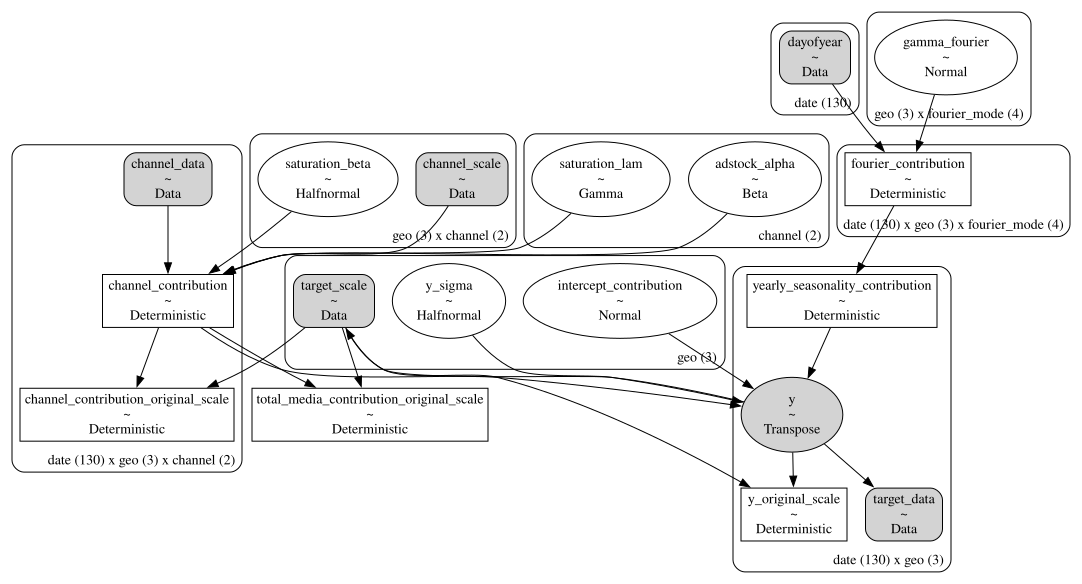

In [37]:
show_graph(m_naive_b, "Naive B")

In [38]:
m_naive_b.fit(X=X_frame, y=y_fit, **sample_kwargs)

NUTS[nutpie]: [y_sigma, gamma_fourier, adstock_alpha, saturation_lam, saturation_beta, intercept_contribution]


<xarray.DataTree>
Group: /
│   Attributes: (12/24)
│       id:                         c2648fd5b170263b
│       model_type:                 MMMM (Multi-Dimensional Marketing Mix Model)
│       version:                    0.0.2
│       sampler_config:             {"nuts_sampler": "nutpie"}
│       model_config:               {"intercept": {"dist": "Normal", "kwargs": {"...
│       __serialization_version__:  1
│       ...                         ...
│       scaling:                    {"__type__": "pymc_marketing.mmm.scaling.Scal...
│       dag:                        null
│       treatment_nodes:            null
│       outcome_node:               null
│       mu_effects:                 []
│       cost_per_unit:              null
├── Group: /posterior
│       Dimensions:                                  (chain: 2, draw: 500, geo: 3,
│                                                     fourier_mode: 4, channel: 2,
│                                                     date: 130)
│       Coordinates:
│         * chain                                    (chain) int64 16B 0 1
│         * draw                                     (draw) int64 4kB 0 1 2 ... 498 499
│         * geo                                      (geo) object 24B 'north' ... 'west'
│         * fourier_mode                             (fourier_mode) object 32B 'sin_1...
│         * channel                                  (channel) object 16B 'tv_spend' ...
│         * date                                     (date) datetime64[ns] 1kB 2021-0...
│       Data variables:
│           gamma_fourier                            (chain, draw, geo, fourier_mode) float64 96kB ...
│           intercept_contribution                   (chain, draw, geo) float64 24kB ...
│           y_sigma                                  (chain, draw, geo) float64 24kB ...
│           adstock_alpha                            (chain, draw, channel) float64 16kB ...
│           saturation_lam                           (chain, draw, channel) float64 16kB ...
│           saturation_beta                          (chain, draw, geo, channel) float64 48kB ...
│           y_original_scale                         (chain, draw, date, geo) float64 3MB ...
│           channel_contribution_original_scale      (chain, draw, date, geo, channel) float64 6MB ...
│           total_media_contribution_original_scale  (chain, draw) float64 8kB 410.4 ...
│           yearly_seasonality_contribution          (chain, draw, date, geo) float64 3MB ...
│           fourier_contribution                     (chain, draw, date, geo, fourier_mode) float64 12MB ...
│           channel_contribution                     (chain, draw, date, geo, channel) float64 6MB ...
│       Attributes:
│           created_at:                 2026-08-17T12:50:04.954040+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                ['chain', 'draw']
│           inference_library:          nutpie
│           inference_library_version:  0.16.11
│           sampling_time:              4.968036890029907
│           tuning_steps:               500
│           pymc_marketing_version:     1.0.0
├── Group: /sample_stats
│       Dimensions:                   (chain: 2, draw: 500)
│       Coordinates:
│         * chain                     (chain) int64 16B 0 1
│         * draw                      (draw) int64 4kB 0 1 2 3 4 ... 495 496 497 498 499
│       Data variables: (12/20)
│           depth                     (chain, draw) uint64 8kB 5 5 7 7 7 6 ... 7 7 7 7 6
│           maxdepth_reached          (chain, draw) bool 1kB False False ... False False
│           step_size                 (chain, draw) float64 8kB 0.1188 0.1121 ... 0.1217
│           transformation_update_id  (chain, draw) int64 8kB 0 0 0 0 0 0 ... 0 0 0 0 0
│           step_size_bar             (chain, draw) float64 8kB 0.1091 0.1091 ... 0.112
│           mean_tree_

#### Naive B+

Adds `category_demand` as a control — partial adjustment for category pressure.


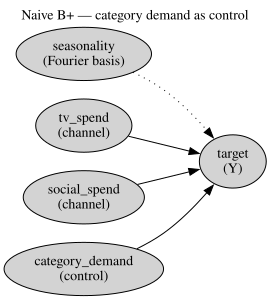

In [39]:
show_causal_dag(
    [
        ("season", "seasonality\n(Fourier basis)", "observed"),
        ("U1", "tv_spend\n(channel)", "observed"),
        ("U2", "social_spend\n(channel)", "observed"),
        ("C", "category_demand\n(control)", "observed"),
        ("Y", "target\n(Y)", "observed"),
    ],
    [
        ("season", "Y", {"style": "dotted"}),
        ("U1", "Y"),
        ("U2", "Y"),
        ("C", "Y"),
    ],
    title="Naive B+ — category demand as control",
)

In [40]:
path = CONFIG_DIR / "funnel_advanced_naive_bplus.yml"
show_yaml(path)
X_frame = df_adv.drop(columns=["y"])
X_build = X_frame
m_naive_bplus = build_mmm_from_yaml(path, X=X_build, y=y_build)

**`funnel_advanced_naive_bplus.yml`**

```yaml
model:
  class: pymc_marketing.mmm.mmm.MMM
  kwargs:
    date_column: date
    target_column: y
    channel_columns: [tv_spend, social_spend]
    control_columns: [category_demand]
    dims: [geo]
    scaling:
      channel: {method: max, dims: []}
      target: {method: max, dims: []}
    adstock:
      class: pymc_marketing.mmm.GeometricAdstock
      kwargs:
        l_max: 8
        priors:
          alpha:
            distribution: Beta
            alpha: 2
            beta: 3
            dims: channel
    saturation:
      class: pymc_marketing.mmm.LogisticSaturation
      kwargs:
        priors:
          lam:
            distribution: Gamma
            mu: 3.0
            sigma: 1.0
            dims: channel
          beta:
            distribution: HalfNormal
            sigma: 1.0
            dims: [geo, channel]
    yearly_seasonality: 2
    model_config:
      intercept:
        distribution: Normal
        mu: 0.2
        sigma: 0.2
        dims: geo
      gamma_fourier:
        distribution: Normal
        mu: 0
        sigma: 0.1
        dims: [geo, fourier_mode]
      likelihood:
        distribution: Normal
        sigma:
          distribution: HalfNormal
          sigma: 0.5
          dims: geo
        dims: [date, geo]
    sampler_config:
      nuts_sampler: nutpie

original_scale_vars: [channel_contribution, y]
```

**Naive B+** — PyMC graph

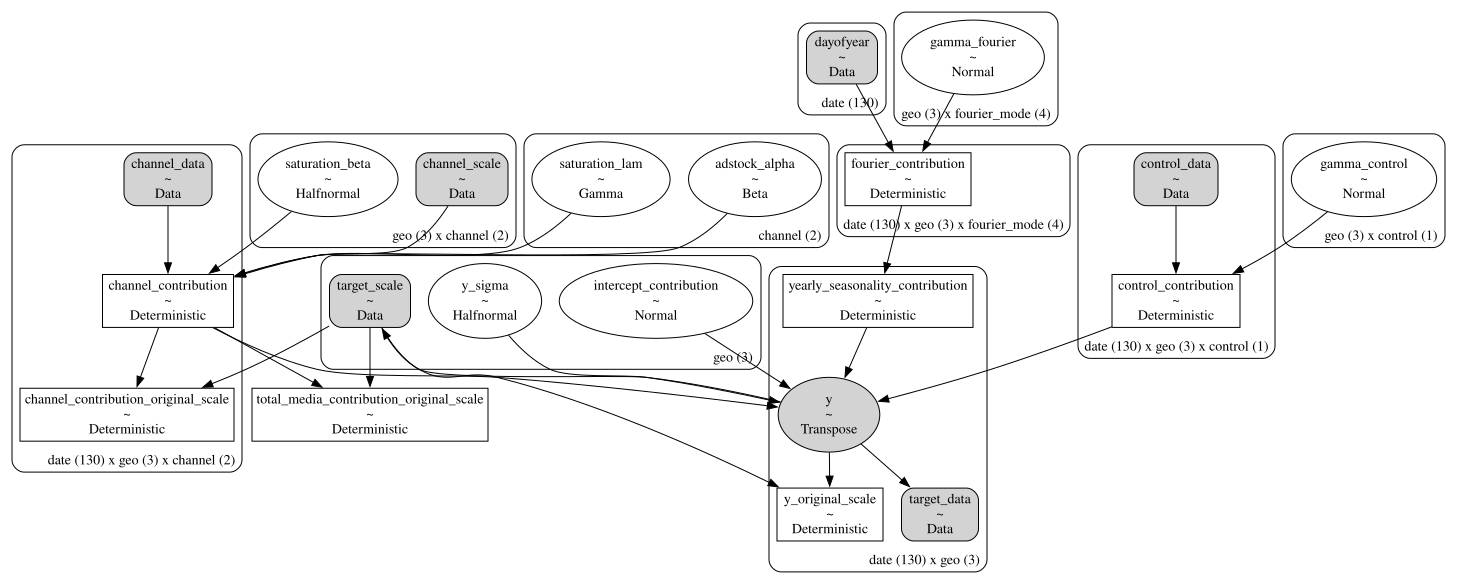

In [41]:
show_graph(m_naive_bplus, "Naive B+")

In [42]:
m_naive_bplus.fit(X=X_frame, y=y_fit, **sample_kwargs)

NUTS[nutpie]: [y_sigma, gamma_fourier, gamma_control, adstock_alpha, saturation_lam, saturation_beta, intercept_contribution]


<xarray.DataTree>
Group: /
│   Attributes: (12/24)
│       id:                         c2648fd5b170263b
│       model_type:                 MMMM (Multi-Dimensional Marketing Mix Model)
│       version:                    0.0.2
│       sampler_config:             {"nuts_sampler": "nutpie"}
│       model_config:               {"intercept": {"dist": "Normal", "kwargs": {"...
│       __serialization_version__:  1
│       ...                         ...
│       scaling:                    {"__type__": "pymc_marketing.mmm.scaling.Scal...
│       dag:                        null
│       treatment_nodes:            null
│       outcome_node:               null
│       mu_effects:                 []
│       cost_per_unit:              null
├── Group: /posterior
│       Dimensions:                                  (chain: 2, draw: 500, geo: 3,
│                                                     fourier_mode: 4, control: 1,
│                                                     channel: 2, date: 130)
│       Coordinates:
│         * chain                                    (chain) int64 16B 0 1
│         * draw                                     (draw) int64 4kB 0 1 2 ... 498 499
│         * geo                                      (geo) object 24B 'north' ... 'west'
│         * fourier_mode                             (fourier_mode) object 32B 'sin_1...
│         * control                                  (control) object 8B 'category_de...
│         * channel                                  (channel) object 16B 'tv_spend' ...
│         * date                                     (date) datetime64[ns] 1kB 2021-0...
│       Data variables: (12/14)
│           gamma_fourier                            (chain, draw, geo, fourier_mode) float64 96kB ...
│           gamma_control                            (chain, draw, geo, control) float64 24kB ...
│           intercept_contribution                   (chain, draw, geo) float64 24kB ...
│           y_sigma                                  (chain, draw, geo) float64 24kB ...
│           adstock_alpha                            (chain, draw, channel) float64 16kB ...
│           saturation_lam                           (chain, draw, channel) float64 16kB ...
│           ...                                       ...
│           channel_contribution_original_scale      (chain, draw, date, geo, channel) float64 6MB ...
│           total_media_contribution_original_scale  (chain, draw) float64 8kB 369.8 ...
│           yearly_seasonality_contribution          (chain, draw, date, geo) float64 3MB ...
│           fourier_contribution                     (chain, draw, date, geo, fourier_mode) float64 12MB ...
│           control_contribution                     (chain, draw, date, geo, control) float64 3MB ...
│           channel_contribution                     (chain, draw, date, geo, channel) float64 6MB ...
│       Attributes:
│           created_at:                 2026-08-17T12:50:18.326136+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                ['chain', 'draw']
│           inference_library:          nutpie
│           inference_library_version:  0.16.11
│           sampling_time:              6.23262095451355
│           tuning_steps:               500
│           pymc_marketing_version:     1.0.0
├── Group: /sample_stats
│       Dimensions:                   (chain: 2, draw: 500)
│       Coordinates:
│         * chain                     (chain) int64 16B 0 1
│         * draw                      (draw) int64 4kB 0 1 2 3 4 ... 495 496 497 498 499
│       Data variables: (12/20)
│           depth                     (chain, draw) uint64 8kB 7 8 8 7 5 6 ... 7 8 7 8 7
│           maxdepth_reached          (chain, draw) bool 1kB False False ... False False
│           step_size                 (chain, draw) float64 8kB 0.09771 ... 0.09365
│           transformation_u

#### Naive B++

Adds time trend `t` as a control instead of category demand.


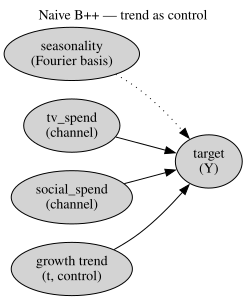

In [43]:
show_causal_dag(
    [
        ("season", "seasonality\n(Fourier basis)", "observed"),
        ("U1", "tv_spend\n(channel)", "observed"),
        ("U2", "social_spend\n(channel)", "observed"),
        ("t", "growth trend\n(t, control)", "observed"),
        ("Y", "target\n(Y)", "observed"),
    ],
    [
        ("season", "Y", {"style": "dotted"}),
        ("U1", "Y"),
        ("U2", "Y"),
        ("t", "Y"),
    ],
    title="Naive B++ — trend as control",
)

In [44]:
path = CONFIG_DIR / "funnel_advanced_naive_bpp.yml"
show_yaml(path)
X_frame = df_adv.drop(columns=["y"])
X_build = X_frame
m_naive_bpp = build_mmm_from_yaml(path, X=X_build, y=y_build)

**`funnel_advanced_naive_bpp.yml`**

```yaml
model:
  class: pymc_marketing.mmm.mmm.MMM
  kwargs:
    date_column: date
    target_column: y
    channel_columns: [tv_spend, social_spend]
    control_columns: [t]
    dims: [geo]
    scaling:
      channel: {method: max, dims: []}
      target: {method: max, dims: []}
    adstock:
      class: pymc_marketing.mmm.GeometricAdstock
      kwargs:
        l_max: 8
        priors:
          alpha:
            distribution: Beta
            alpha: 2
            beta: 3
            dims: channel
    saturation:
      class: pymc_marketing.mmm.LogisticSaturation
      kwargs:
        priors:
          lam:
            distribution: Gamma
            mu: 3.0
            sigma: 1.0
            dims: channel
          beta:
            distribution: HalfNormal
            sigma: 1.0
            dims: [geo, channel]
    yearly_seasonality: 2
    model_config:
      intercept:
        distribution: Normal
        mu: 0.2
        sigma: 0.2
        dims: geo
      gamma_fourier:
        distribution: Normal
        mu: 0
        sigma: 0.1
        dims: [geo, fourier_mode]
      likelihood:
        distribution: Normal
        sigma:
          distribution: HalfNormal
          sigma: 0.5
          dims: geo
        dims: [date, geo]
    sampler_config:
      nuts_sampler: nutpie

original_scale_vars: [channel_contribution, y]
```

**Naive B++** — PyMC graph

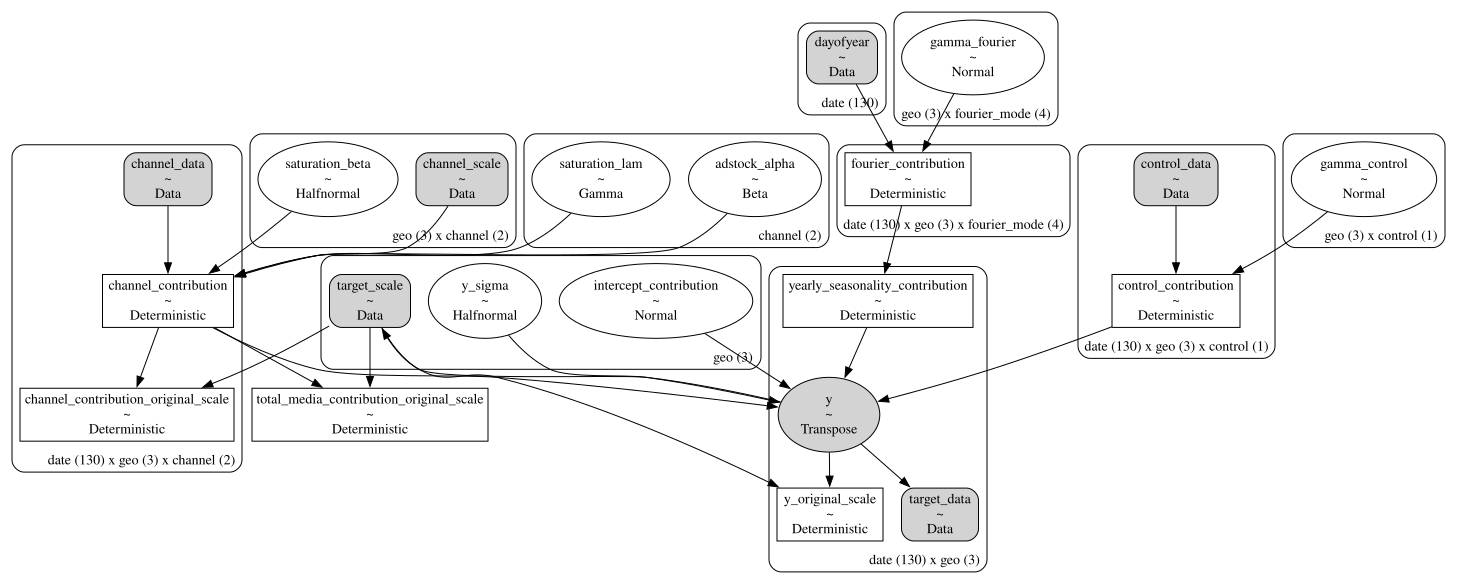

In [45]:
show_graph(m_naive_bpp, "Naive B++")

In [46]:
m_naive_bpp.fit(X=X_frame, y=y_fit, **sample_kwargs)

NUTS[nutpie]: [y_sigma, gamma_fourier, gamma_control, adstock_alpha, saturation_lam, saturation_beta, intercept_contribution]


<xarray.DataTree>
Group: /
│   Attributes: (12/24)
│       id:                         c2648fd5b170263b
│       model_type:                 MMMM (Multi-Dimensional Marketing Mix Model)
│       version:                    0.0.2
│       sampler_config:             {"nuts_sampler": "nutpie"}
│       model_config:               {"intercept": {"dist": "Normal", "kwargs": {"...
│       __serialization_version__:  1
│       ...                         ...
│       scaling:                    {"__type__": "pymc_marketing.mmm.scaling.Scal...
│       dag:                        null
│       treatment_nodes:            null
│       outcome_node:               null
│       mu_effects:                 []
│       cost_per_unit:              null
├── Group: /posterior
│       Dimensions:                                  (chain: 2, draw: 500, geo: 3,
│                                                     fourier_mode: 4, control: 1,
│                                                     channel: 2, date: 130)
│       Coordinates:
│         * chain                                    (chain) int64 16B 0 1
│         * draw                                     (draw) int64 4kB 0 1 2 ... 498 499
│         * geo                                      (geo) object 24B 'north' ... 'west'
│         * fourier_mode                             (fourier_mode) object 32B 'sin_1...
│         * control                                  (control) object 8B 't'
│         * channel                                  (channel) object 16B 'tv_spend' ...
│         * date                                     (date) datetime64[ns] 1kB 2021-0...
│       Data variables: (12/14)
│           gamma_fourier                            (chain, draw, geo, fourier_mode) float64 96kB ...
│           gamma_control                            (chain, draw, geo, control) float64 24kB ...
│           intercept_contribution                   (chain, draw, geo) float64 24kB ...
│           y_sigma                                  (chain, draw, geo) float64 24kB ...
│           adstock_alpha                            (chain, draw, channel) float64 16kB ...
│           saturation_lam                           (chain, draw, channel) float64 16kB ...
│           ...                                       ...
│           channel_contribution_original_scale      (chain, draw, date, geo, channel) float64 6MB ...
│           total_media_contribution_original_scale  (chain, draw) float64 8kB 369.3 ...
│           yearly_seasonality_contribution          (chain, draw, date, geo) float64 3MB ...
│           fourier_contribution                     (chain, draw, date, geo, fourier_mode) float64 12MB ...
│           control_contribution                     (chain, draw, date, geo, control) float64 3MB ...
│           channel_contribution                     (chain, draw, date, geo, channel) float64 6MB ...
│       Attributes:
│           created_at:                 2026-08-17T12:50:31.582300+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                ['chain', 'draw']
│           inference_library:          nutpie
│           inference_library_version:  0.16.11
│           sampling_time:              6.2358880043029785
│           tuning_steps:               500
│           pymc_marketing_version:     1.0.0
├── Group: /sample_stats
│       Dimensions:                   (chain: 2, draw: 500)
│       Coordinates:
│         * chain                     (chain) int64 16B 0 1
│         * draw                      (draw) int64 4kB 0 1 2 3 4 ... 495 496 497 498 499
│       Data variables: (12/20)
│           depth                     (chain, draw) uint64 8kB 7 6 7 7 7 5 ... 7 7 7 7 7
│           maxdepth_reached          (chain, draw) bool 1kB False False ... False False
│           step_size                 (chain, draw) float64 8kB 0.09322 ... 0.1038
│           transformation_update_id  (

#### Naive C

Puts `search_volume` in `channel_columns` — proxies lower-funnel activity as a channel.


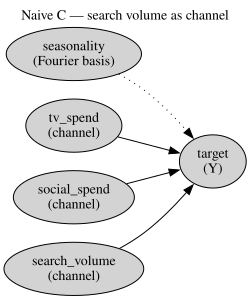

In [47]:
show_causal_dag(
    [
        ("season", "seasonality\n(Fourier basis)", "observed"),
        ("U1", "tv_spend\n(channel)", "observed"),
        ("U2", "social_spend\n(channel)", "observed"),
        ("S", "search_volume\n(channel)", "observed"),
        ("Y", "target\n(Y)", "observed"),
    ],
    [
        ("season", "Y", {"style": "dotted"}),
        ("U1", "Y"),
        ("U2", "Y"),
        ("S", "Y"),
    ],
    title="Naive C — search volume as channel",
)

In [48]:
path = CONFIG_DIR / "funnel_advanced_naive_c.yml"
show_yaml(path)
X_frame = df_naive_c.drop(columns=["y"])
X_build = X_frame
m_naive_c = build_mmm_from_yaml(path, X=X_build, y=y_build)

**`funnel_advanced_naive_c.yml`**

```yaml
model:
  class: pymc_marketing.mmm.mmm.MMM
  kwargs:
    date_column: date
    target_column: y
    channel_columns: [tv_spend, social_spend, search_volume]
    dims: [geo]
    scaling:
      channel: {method: max, dims: []}
      target: {method: max, dims: []}
    adstock:
      class: pymc_marketing.mmm.GeometricAdstock
      kwargs:
        l_max: 8
        priors:
          alpha:
            distribution: Beta
            alpha: 2
            beta: 3
            dims: channel
    saturation:
      class: pymc_marketing.mmm.LogisticSaturation
      kwargs:
        priors:
          lam:
            distribution: Gamma
            mu: 3.0
            sigma: 1.0
            dims: channel
          beta:
            distribution: HalfNormal
            sigma: 1.0
            dims: [geo, channel]
    yearly_seasonality: 2
    model_config:
      intercept:
        distribution: Normal
        mu: 0.2
        sigma: 0.2
        dims: geo
      gamma_fourier:
        distribution: Normal
        mu: 0
        sigma: 0.1
        dims: [geo, fourier_mode]
      likelihood:
        distribution: Normal
        sigma:
          distribution: HalfNormal
          sigma: 0.5
          dims: geo
        dims: [date, geo]
    sampler_config:
      nuts_sampler: nutpie

original_scale_vars: [channel_contribution, y]
```

**Naive C** — PyMC graph

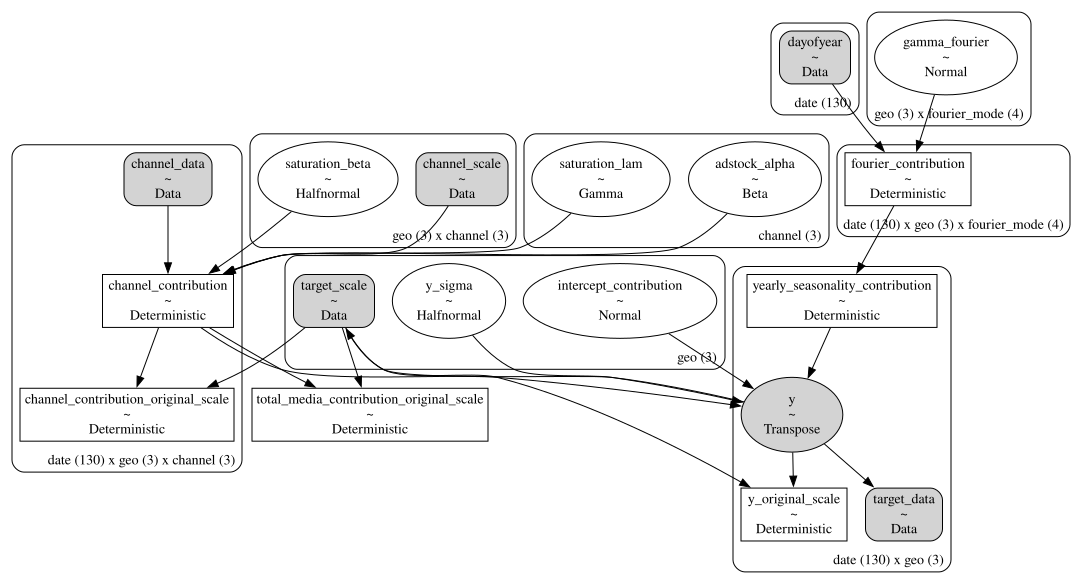

In [49]:
show_graph(m_naive_c, "Naive C")

In [50]:
m_naive_c.fit(X=X_frame, y=y_fit, **sample_kwargs)

NUTS[nutpie]: [y_sigma, gamma_fourier, adstock_alpha, saturation_lam, saturation_beta, intercept_contribution]


<xarray.DataTree>
Group: /
│   Attributes: (12/24)
│       id:                         c2648fd5b170263b
│       model_type:                 MMMM (Multi-Dimensional Marketing Mix Model)
│       version:                    0.0.2
│       sampler_config:             {"nuts_sampler": "nutpie"}
│       model_config:               {"intercept": {"dist": "Normal", "kwargs": {"...
│       __serialization_version__:  1
│       ...                         ...
│       scaling:                    {"__type__": "pymc_marketing.mmm.scaling.Scal...
│       dag:                        null
│       treatment_nodes:            null
│       outcome_node:               null
│       mu_effects:                 []
│       cost_per_unit:              null
├── Group: /posterior
│       Dimensions:                                  (chain: 2, draw: 500, geo: 3,
│                                                     fourier_mode: 4, channel: 3,
│                                                     date: 130)
│       Coordinates:
│         * chain                                    (chain) int64 16B 0 1
│         * draw                                     (draw) int64 4kB 0 1 2 ... 498 499
│         * geo                                      (geo) object 24B 'north' ... 'west'
│         * fourier_mode                             (fourier_mode) object 32B 'sin_1...
│         * channel                                  (channel) object 24B 'tv_spend' ...
│         * date                                     (date) datetime64[ns] 1kB 2021-0...
│       Data variables:
│           gamma_fourier                            (chain, draw, geo, fourier_mode) float64 96kB ...
│           intercept_contribution                   (chain, draw, geo) float64 24kB ...
│           y_sigma                                  (chain, draw, geo) float64 24kB ...
│           adstock_alpha                            (chain, draw, channel) float64 24kB ...
│           saturation_lam                           (chain, draw, channel) float64 24kB ...
│           saturation_beta                          (chain, draw, geo, channel) float64 72kB ...
│           y_original_scale                         (chain, draw, date, geo) float64 3MB ...
│           channel_contribution_original_scale      (chain, draw, date, geo, channel) float64 9MB ...
│           total_media_contribution_original_scale  (chain, draw) float64 8kB 386.7 ...
│           yearly_seasonality_contribution          (chain, draw, date, geo) float64 3MB ...
│           fourier_contribution                     (chain, draw, date, geo, fourier_mode) float64 12MB ...
│           channel_contribution                     (chain, draw, date, geo, channel) float64 9MB ...
│       Attributes:
│           created_at:                 2026-08-17T12:50:49.467627+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                ['chain', 'draw']
│           inference_library:          nutpie
│           inference_library_version:  0.16.11
│           sampling_time:              11.01137399673462
│           tuning_steps:               500
│           pymc_marketing_version:     1.0.0
├── Group: /sample_stats
│       Dimensions:                   (chain: 2, draw: 500)
│       Coordinates:
│         * chain                     (chain) int64 16B 0 1
│         * draw                      (draw) int64 4kB 0 1 2 3 4 ... 495 496 497 498 499
│       Data variables: (12/20)
│           depth                     (chain, draw) uint64 8kB 8 8 7 8 7 8 ... 8 7 7 7 8
│           maxdepth_reached          (chain, draw) bool 1kB False False ... False False
│           step_size                 (chain, draw) float64 8kB 0.07651 ... 0.08184
│           transformation_update_id  (chain, draw) int64 8kB 0 0 0 0 0 0 ... 0 0 0 0 0
│           step_size_bar             (chain, draw) float64 8kB 0.07606 ... 0.07447
│           mean_tree_accept   

#### Funnel

`GeoFunnelEffect` with likelihoods on `lower_spend` and `search_volume`, plus `extra_vars` for mediators.


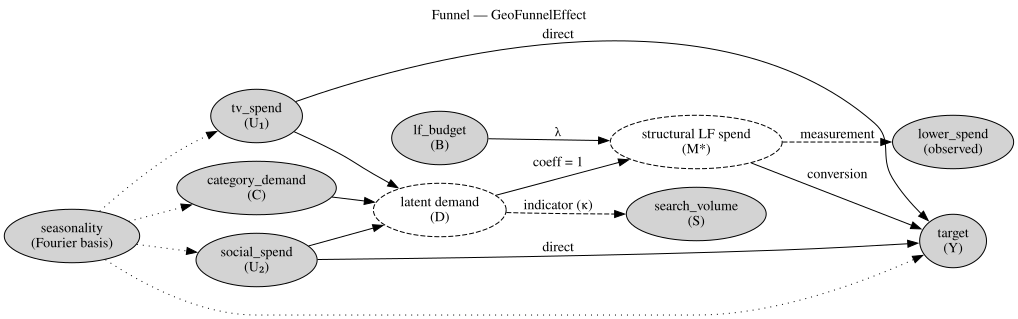

In [51]:
show_causal_dag(
    [
        ("season", "seasonality\n(Fourier basis)", "observed"),
        ("U1", "tv_spend\n(U₁)", "observed"),
        ("U2", "social_spend\n(U₂)", "observed"),
        ("C", "category_demand\n(C)", "observed"),
        ("B", "lf_budget\n(B)", "observed"),
        ("D", "latent demand\n(D)", "latent"),
        ("MS", "structural LF spend\n(M*)", "latent"),
        ("M", "lower_spend\n(observed)", "observed"),
        ("S", "search_volume\n(S)", "observed"),
        ("Y", "target\n(Y)", "observed"),
    ],
    [
        ("season", "U1", {"style": "dotted"}),
        ("season", "U2", {"style": "dotted"}),
        ("season", "C", {"style": "dotted"}),
        ("season", "Y", {"style": "dotted"}),
        ("U1", "Y", {"label": "direct"}),
        ("U2", "Y", {"label": "direct"}),
        ("U1", "D"),
        ("U2", "D"),
        ("C", "D"),
        ("D", "MS", {"label": "coeff = 1"}),
        ("B", "MS", {"label": "λ"}),
        ("MS", "M", {"label": "measurement", "style": "dashed"}),
        ("D", "S", {"label": "indicator (κ)", "style": "dashed"}),
        ("MS", "Y", {"label": "conversion"}),
    ],
    title="Funnel — GeoFunnelEffect",
)

In [52]:
path = CONFIG_DIR / "funnel_advanced.yml"
show_yaml(path)
X_frame = df_adv.drop(columns=["y"])
X_build = ds_fit
m_funnel_adv = build_mmm_from_yaml(path, X=X_build, y=y_build)

**`funnel_advanced.yml`**

```yaml
model:
  class: pymc_marketing.mmm.mmm.MMM
  kwargs:
    date_column: date
    target_column: y
    channel_columns: [tv_spend, social_spend]
    dims: [geo]
    scaling:
      channel: {method: max, dims: []}
      target: {method: max, dims: []}
    adstock:
      class: pymc_marketing.mmm.GeometricAdstock
      kwargs:
        l_max: 8
        priors:
          alpha:
            distribution: Beta
            alpha: 2
            beta: 3
            dims: channel
    saturation:
      class: pymc_marketing.mmm.LogisticSaturation
      kwargs:
        priors:
          lam:
            distribution: Gamma
            mu: 3.0
            sigma: 1.0
            dims: channel
          beta:
            distribution: HalfNormal
            sigma: 1.0
            dims: [geo, channel]
    yearly_seasonality: 2
    model_config:
      intercept:
        distribution: Normal
        mu: 0.2
        sigma: 0.2
        dims: geo
      gamma_fourier:
        distribution: Normal
        mu: 0
        sigma: 0.1
        dims: [geo, fourier_mode]
      likelihood:
        distribution: Normal
        sigma:
          distribution: HalfNormal
          sigma: 0.5
          dims: geo
        dims: [date, geo]
    sampler_config:
      nuts_sampler: nutpie

extra_vars: [lower_spend, search_volume, category_demand, lf_budget]

effects:
  - class: GeoFunnelEffect
    kwargs:
      data_vars: [lower_spend, search_volume, category_demand, lf_budget]
      prefix: funnel
      upper_transform:
        class: pymc_marketing.mmm.media_transformation.MediaTransformation
        kwargs:
          adstock_first: true
          dims: [geo, channel]
          adstock:
            class: pymc_marketing.mmm.GeometricAdstock
            kwargs:
              l_max: 8
              prefix: adstock_uf
              priors:
                alpha:
                  distribution: Beta
                  alpha: 2
                  beta: 3
                  dims: channel
          saturation:
            class: pymc_marketing.mmm.LogisticSaturation
            kwargs:
              prefix: sat_uf
              priors:
                lam:
                  distribution: Gamma
                  mu: 2.0
                  sigma: 1.0
                  dims: channel
                beta:
                  distribution: HalfNormal
                  sigma: 1.0
                  dims: [geo, channel]
      demand_transform:
        class: pymc_marketing.mmm.media_transformation.MediaTransformation
        kwargs:
          adstock_first: true
          dims: [geo]
          adstock:
            class: pymc_marketing.mmm.GeometricAdstock
            kwargs:
              l_max: 8
              prefix: adstock_lf
              priors:
                alpha:
                  distribution: Beta
                  alpha: 2
                  beta: 3
                  dims: geo
          saturation:
            class: pymc_marketing.mmm.LogisticSaturation
            kwargs:
              prefix: sat_lf
              priors:
                lam:
                  distribution: Gamma
                  mu: 1.5
                  sigma: 0.5
                beta:
                  distribution: HalfNormal
                  sigma: 1.0
                  dims: geo

original_scale_vars: [channel_contribution, funnel_effect_contribution, y]
```

**Funnel** — PyMC graph

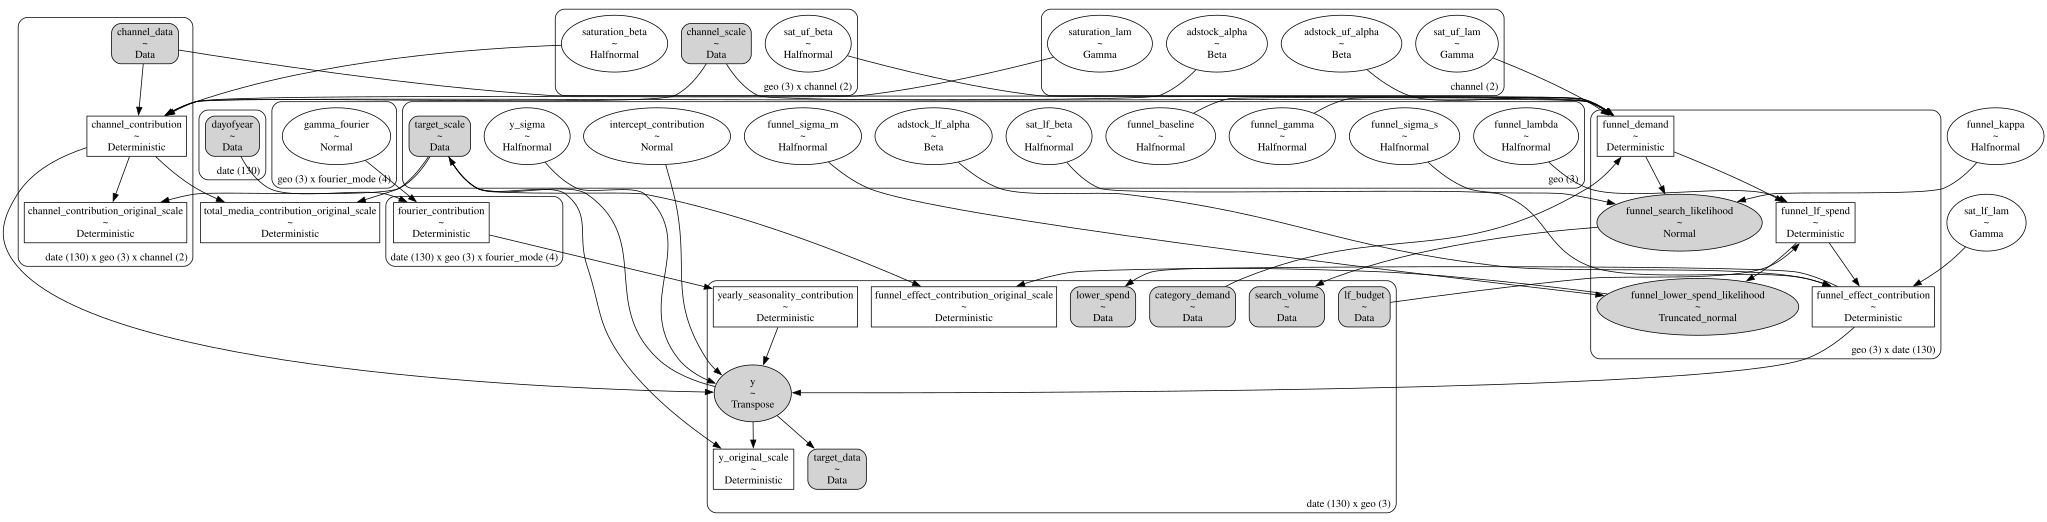

In [53]:
show_graph(m_funnel_adv, "Funnel")

In [54]:
m_funnel_adv.fit(X=X_frame, y=y_fit, **sample_kwargs)

NUTS[nutpie]: [y_sigma, adstock_lf_alpha, funnel_lambda, adstock_uf_alpha, sat_uf_lam, sat_uf_beta, funnel_gamma, funnel_baseline, sat_lf_lam, sat_lf_beta, gamma_fourier, adstock_alpha, saturation_lam, saturation_beta, intercept_contribution, funnel_sigma_s, funnel_kappa, funnel_sigma_m]


<xarray.DataTree>
Group: /
│   Attributes: (12/24)
│       id:                         c2648fd5b170263b
│       model_type:                 MMMM (Multi-Dimensional Marketing Mix Model)
│       version:                    0.0.2
│       sampler_config:             {"nuts_sampler": "nutpie"}
│       model_config:               {"intercept": {"dist": "Normal", "kwargs": {"...
│       __serialization_version__:  1
│       ...                         ...
│       scaling:                    {"__type__": "pymc_marketing.mmm.scaling.Scal...
│       dag:                        null
│       treatment_nodes:            null
│       outcome_node:               null
│       mu_effects:                 [{"__type__": "__main__.GeoFunnelEffect", "da...
│       cost_per_unit:              null
├── Group: /posterior
│       Dimensions:                                    (chain: 2, draw: 500, geo: 3,
│                                                       fourier_mode: 4, channel: 2,
│                                                       date: 130)
│       Coordinates:
│         * chain                                      (chain) int64 16B 0 1
│         * draw                                       (draw) int64 4kB 0 1 ... 498 499
│         * geo                                        (geo) object 24B 'north' ... '...
│         * fourier_mode                               (fourier_mode) object 32B 'sin...
│         * channel                                    (channel) object 16B 'tv_spend...
│         * date                                       (date) datetime64[ns] 1kB 2021...
│       Data variables: (12/28)
│           gamma_fourier                              (chain, draw, geo, fourier_mode) float64 96kB ...
│           intercept_contribution                     (chain, draw, geo) float64 24kB ...
│           y_sigma                                    (chain, draw, geo) float64 24kB ...
│           adstock_lf_alpha                           (chain, draw, geo) float64 24kB ...
│           funnel_lambda                              (chain, draw, geo) float64 24kB ...
│           adstock_uf_alpha                           (chain, draw, channel) float64 16kB ...
│           ...                                         ...
│           funnel_effect_contribution                 (chain, draw, geo, date) float64 3MB ...
│           funnel_lf_spend                            (chain, draw, geo, date) float64 3MB ...
│           funnel_demand                              (chain, draw, geo, date) float64 3MB ...
│           yearly_seasonality_contribution            (chain, draw, date, geo) float64 3MB ...
│           fourier_contribution                       (chain, draw, date, geo, fourier_mode) float64 12MB ...
│           channel_contribution                       (chain, draw, date, geo, channel) float64 6MB ...
│       Attributes:
│           created_at:                 2026-08-17T12:52:13.496600+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                ['chain', 'draw']
│           inference_library:          nutpie
│           inference_library_version:  0.16.11
│           sampling_time:              57.973450899124146
│           tuning_steps:               500
│           pymc_marketing_version:     1.0.0
├── Group: /sample_stats
│       Dimensions:                   (chain: 2, draw: 500)
│       Coordinates:
│         * chain                     (chain) int64 16B 0 1
│         * draw                      (draw) int64 4kB 0 1 2 3 4 ... 495 496 497 498 499
│       Data variables: (12/20)
│           depth                     (chain, draw) uint64 8kB 8 9 9 9 9 9 ... 8 9 8 8 8
│           maxdepth_reached          (chain, draw) bool 1kB False False ... False False
│           step_size                 (chain, draw) float64 8kB 0.0548 ... 0.06863
│           transformation_update_id  (chain, draw) int64 8kB 0 0 0 0 0 0 

In [55]:
advanced_models = {
    "Naive A": m_naive_a,
    "Naive B": m_naive_b,
    "Naive B+": m_naive_bplus,
    "Naive B++": m_naive_bpp,
    "Naive C": m_naive_c,
    "Funnel": m_funnel_adv,
}

### Step 4 — Compare TV ROAS

TV is the primary upper-funnel channel. Differences here reflect how each spec handles the mediated path through lower-funnel demand.


In [56]:
def tv_roas(model):
    roas = model.incrementality.contribution_over_spend(frequency="all_time")
    return float(roas.sel(channel="tv_spend").mean())


advanced_roas = {label: tv_roas(m) for label, m in advanced_models.items()}
pd.Series(advanced_roas, name="TV ROAS (incrementality)").to_frame().T

,Naive A,Naive B,Naive B+,Naive B++,Naive C,Funnel
TV ROAS (incrementality),0.435054,0.50641,0.469898,0.480958,0.429927,0.449742


## Summary

- `model:` covers standard MMM kwargs; `effects:` and `extra_vars` extend the graph for funnel structure.
- Printing YAML alongside graphviz makes the config → DAG mapping concrete.
- `build_mmm_from_yaml` converts DataFrames with `extra_vars` to `xr.Dataset` automatically for funnel models.
- Promoting `FunnelEffect` / `GeoFunnelEffect` into the library is the natural next step.


In [57]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pymc_marketing,pytensor

Last updated: Mon, 17 Aug 2026

Python implementation: CPython
Python version       : 3.12.10
IPython version      : 9.15.0

pymc_marketing: 1.0.0
pytensor      : 3.0.7

IPython       : 9.15.0
arviz         : 1.2.0
graphviz      : 0.21
matplotlib    : 3.10.9
numpy         : 2.4.6
pandas        : 2.3.3
pydantic      : 2.13.4
pymc          : 6.0.1
pymc_extras   : 0.12.2.dev1+gee8cc37df
pymc_marketing: 1.0.0
pytensor      : 3.0.7
xarray        : 2026.4.0

Watermark: 2.6.0

